# Melbourne Housing: Market Segmentation and Advanced Price Prediction Pipeline

**Course:** Machine Learning  
**Project:** Individual Final Project  
**Author:** Juan Pablo Ariza Gallo 
**Date:** March 2026  


<a id="summary"></a>
## 1. Summary


### Project Objective

In this project, I act as a Lead Data Scientist for a property valuation consultancy. The objective is to develop a high-performance machine learning pipeline capable of accurately predicting property prices in the Melbourne housing market.

This project integrates **Data Engineering, Unsupervised Learning, Supervised Learning, and Deep Learning** into a unified and reproducible pipeline.

A key focus of this project is the implementation of a **hybrid analytical framework**, where insights obtained from unsupervised learning techniques such as dimensionality reduction and clustering are used to engineer new features that enhance the performance of predictive models.

---

### Expected Outcome

The final outcome is a professional-grade machine learning pipeline capable of delivering accurate, interpretable, and production-ready property price predictions, supported by rigorous evaluation and technical justification.


<a id="table-of-contents"></a>
## 2. Table of contents

- [1. Summary](#1-summary)
- [2. Table of contents](#2-table-of-contents)
- [3. Data Loading & Introduction](#3-data-loading--introduction)
- [4. Phase 1 — Data Engineering](#4-phase-1--data-engineering)
  - [4.1 Missing Values](#41-missing-values)
  - [4.2 Outliers](#42-outliers)
  - [4.3 Feature Engineering & Preprocessing](#43-feature-engineering--preprocessing)
  - [4.4 Final Analysis-Ready Dataset](#44-final-analysis-ready-dataset)
- [5. Phase 2 — Unsupervised Feature Discovery](#5-phase-2--unsupervised-feature-discovery)
  - [5.1 Dimensionality Reduction (PCA)](#51-dimensionality-reduction-pca)
  - [5.2 Clustering & Market Segmentation](#52-clustering--market-segmentation)
  - [5.3 The Bridge: Augmented Dataset](#53-the-bridge-augmented-dataset)
- [6. Phase 3 — Model Tournament (A vs B)](#6-phase-3--model-tournament-a-vs-b)
  - [6.1 Evaluation Design & Metrics](#61-evaluation-design--metrics)
  - [6.2 Baseline: Linear / Regularized Regression](#62-baseline-linear--regularized-regression)
  - [6.3 Ensemble: Hyperparameter Optimization](#63-ensemble-hyperparameter-optimization)
  - [6.4 Deep Learner: ANN + Learning Curves](#64-deep-learner-ann--learning-curves)
- [7. Phase 4 — Critical Analysis](#7-phase-4--critical-analysis)
  - [7.1 Performance Audit](#71-performance-audit)
  - [7.2 Ethical Review](#72-ethical-review)
- [8. Conclusion & Future Improvements](#8-conclusion--future-improvements)


<a id="data-loading-introduction"></a>
## 3. Data Loading & Introduction

In [11]:
import kagglehub
import pandas as pd
import os

# Use the original dataset revision, or set MELBOURNE_HOUSING_CSV to a local copy.
csv_path = os.environ.get("MELBOURNE_HOUSING_CSV")
if not csv_path:
    path = kagglehub.dataset_download("anthonypino/melbourne-housing-market/versions/27")
    csv_path = os.path.join(path, "Melbourne_housing_FULL.csv")

df = pd.read_csv(csv_path)

print("Using FULL dataset (version 27)")
print("Shape:", df.shape)

display(df.head())


[local-path] TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: [local-path]
Using FULL dataset
Shape: (34857, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [12]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Duplicates
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count:,}")




Duplicate rows: 1


In [13]:
# Missing values
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] > 0]
print("\nMissing values (only columns with missing):")
display(missing_table)




Missing values (only columns with missing):


,missing_count,missing_pct
BuildingArea,21115,60.58
YearBuilt,19306,55.39
Landsize,11810,33.88
Car,8728,25.04
Bathroom,8226,23.60
Bedroom2,8217,23.57
Lattitude,7976,22.88
Longtitude,7976,22.88
Price,7610,21.83
Regionname,3,0.01


In [14]:
# 4) Separate numeric vs categorical
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"\nNumeric columns ({len(num_cols)}): {num_cols}")
print(f"\nCategorical columns ({len(cat_cols)}): {cat_cols}")




Numeric columns (13): ['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']

Categorical columns (8): ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']


In [15]:
# Cardinality for categoricals (label analysis)
if len(cat_cols) > 0:
    card = pd.DataFrame({
        "n_unique": df[cat_cols].nunique(dropna=True),
        "top": [df[c].mode(dropna=True).iloc[0] if df[c].dropna().shape[0] > 0 else None for c in cat_cols],
        "top_freq": [df[c].value_counts(dropna=True).iloc[0] if df[c].dropna().shape[0] > 0 else 0 for c in cat_cols]
    }).sort_values("n_unique", ascending=False)
    print("\nCategorical label/cardinality summary:")
    display(card)




Categorical label/cardinality summary:


,n_unique,top,top_freq
Address,34009,5 Charles St,6
SellerG,388,Jellis,3359
Suburb,351,Reservoir,844
Date,78,28/10/2017,1119
CouncilArea,33,Boroondara City Council,3675
Method,9,S,19744
Regionname,8,Southern Metropolitan,11836
Type,3,h,23980


In [16]:
# 5) Descriptive statistics
print("\nDescriptive stats — numeric:")
display(df[num_cols].describe().T)

if len(cat_cols) > 0:
    print("\nDescriptive stats — categorical:")
    display(df[cat_cols].describe().T)




Descriptive stats — numeric:


,count,mean,std,min,25%,50%,75%,max
Rooms,34857.0,3.031012e+00,0.969933,1.00000,2.00000,3.0000,4.000000e+00,1.600000e+01
Price,27247.0,1.050173e+06,641467.130105,85000.00000,635000.00000,870000.0000,1.295000e+06,1.120000e+07
Distance,34856.0,1.118493e+01,6.788892,0.00000,6.40000,10.3000,1.400000e+01,4.810000e+01
Postcode,34856.0,3.116063e+03,109.023903,3000.00000,3051.00000,3103.0000,3.156000e+03,3.978000e+03
Bedroom2,26640.0,3.084647e+00,0.980690,0.00000,2.00000,3.0000,4.000000e+00,3.000000e+01
Bathroom,26631.0,1.624798e+00,0.724212,0.00000,1.00000,2.0000,2.000000e+00,1.200000e+01
Car,26129.0,1.728845e+00,1.010771,0.00000,1.00000,2.0000,2.000000e+00,2.600000e+01
Landsize,23047.0,5.935990e+02,3398.841946,0.00000,224.00000,521.0000,6.700000e+02,4.330140e+05
BuildingArea,13742.0,1.602564e+02,401.267060,0.00000,102.00000,136.0000,1.880000e+02,4.451500e+04
YearBuilt,15551.0,1.965290e+03,37.328178,1196.00000,1940.00000,1970.0000,2.000000e+03,2.106000e+03



Descriptive stats — categorical:


,count,unique,top,freq
Suburb,34857,351,Reservoir,844
Address,34857,34009,5 Charles St,6
Type,34857,3,h,23980
Method,34857,9,S,19744
SellerG,34857,388,Jellis,3359
Date,34857,78,28/10/2017,1119
CouncilArea,34854,33,Boroondara City Council,3675
Regionname,34854,8,Southern Metropolitan,11836



Target variable: Price


count    2.724700e+04
mean     1.050173e+06
std      6.414671e+05
min      8.500000e+04
25%      6.350000e+05
50%      8.700000e+05
75%      1.295000e+06
max      1.120000e+07
Name: Price, dtype: float64

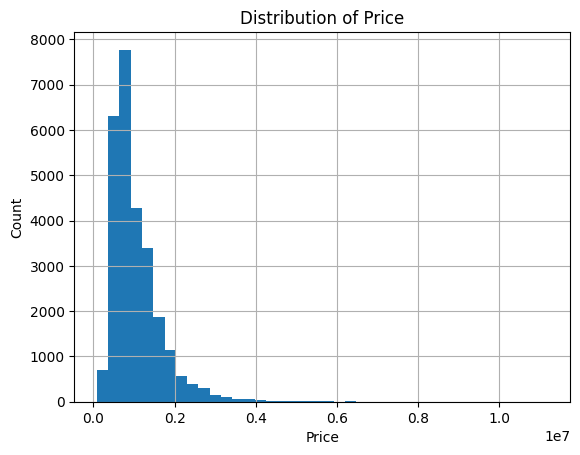

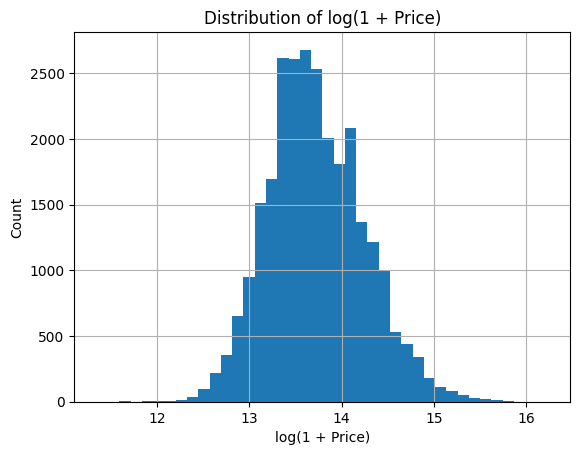

In [17]:
# 6) Target inspection (Price)
if "Price" in df.columns:
    print("\nTarget variable: Price")
    display(df["Price"].describe())

    plt.figure()
    df["Price"].dropna().hist(bins=40)
    plt.title("Distribution of Price")
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.show()

    # Log-transform view 
    plt.figure()
    np.log1p(df["Price"].dropna()).hist(bins=40)
    plt.title("Distribution of log(1 + Price)")
    plt.xlabel("log(1 + Price)")
    plt.ylabel("Count")
    plt.show()
else:
    print("\n⚠️ Column 'Price' not found. Check dataset columns.")




Plotting distributions for up to 12 numeric variables...


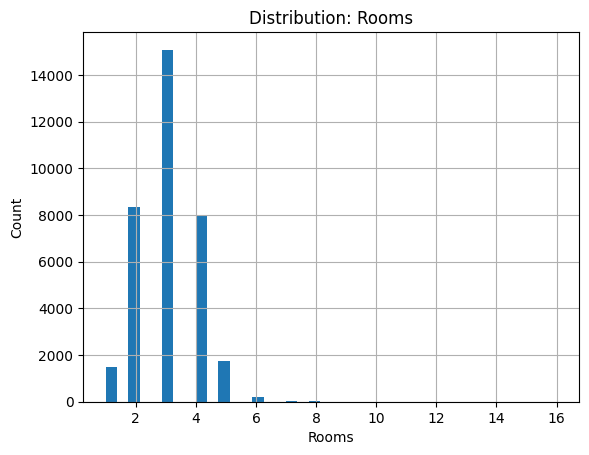

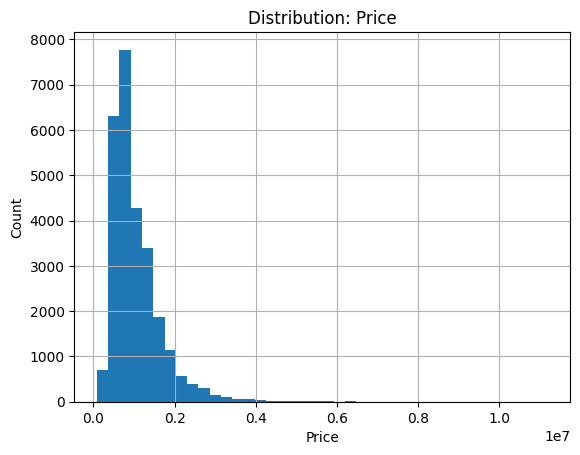

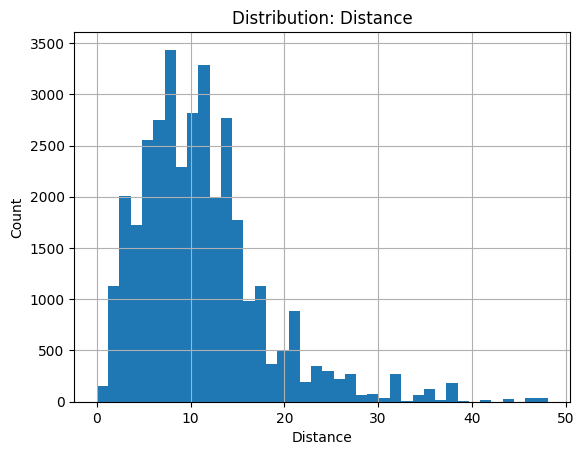

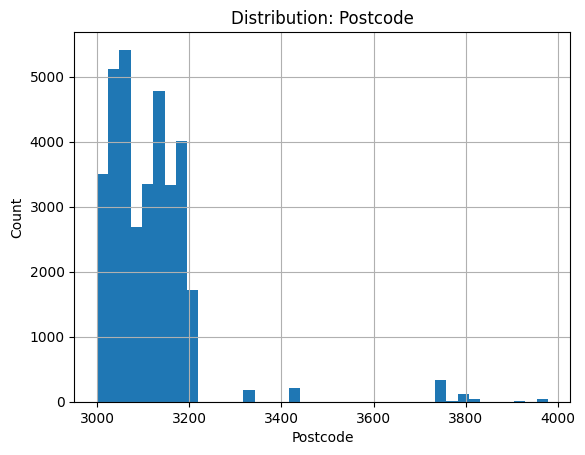

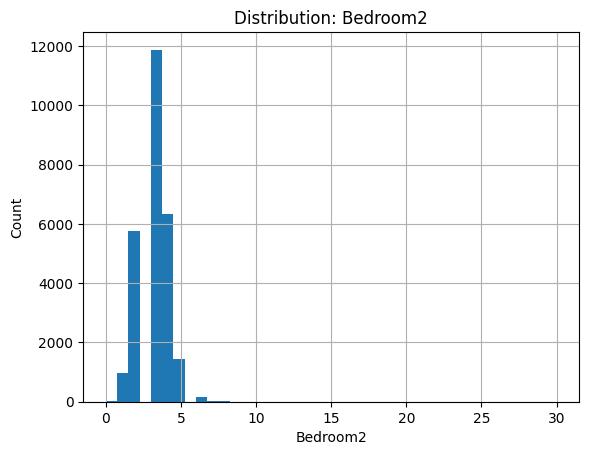

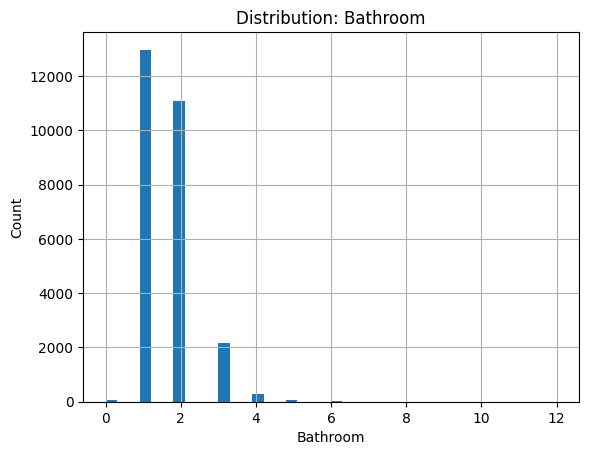

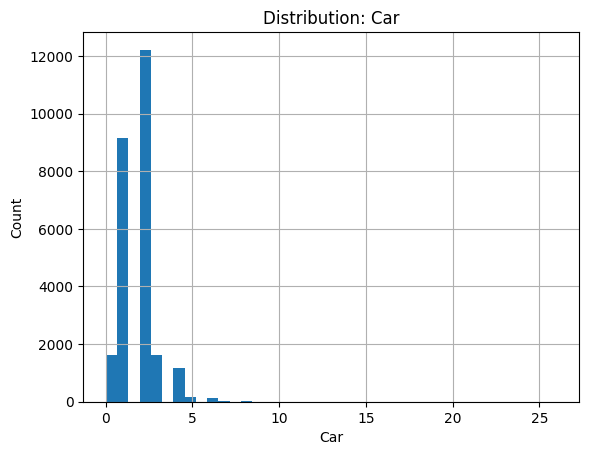

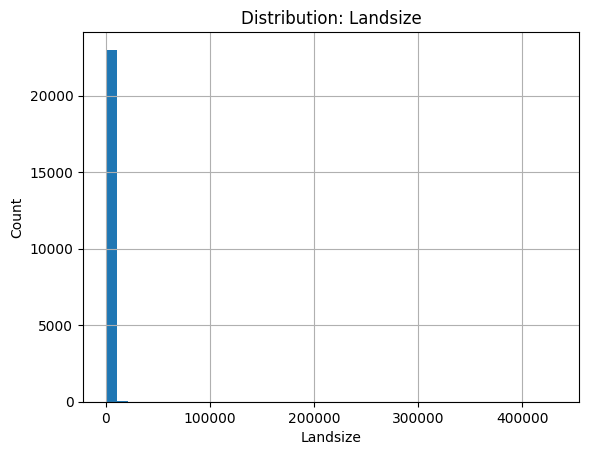

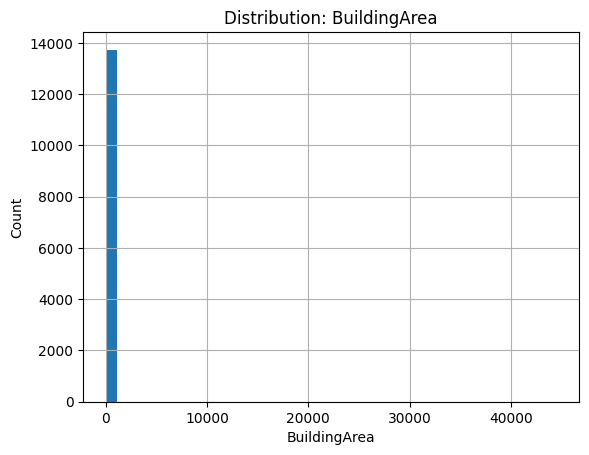

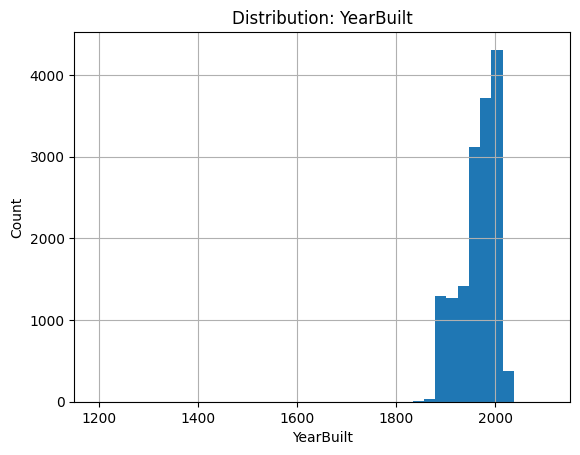

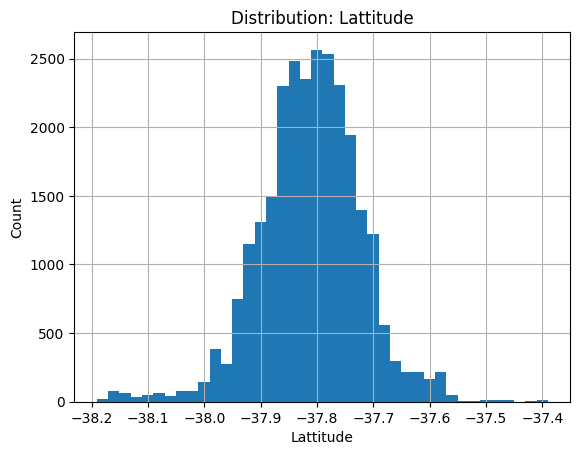

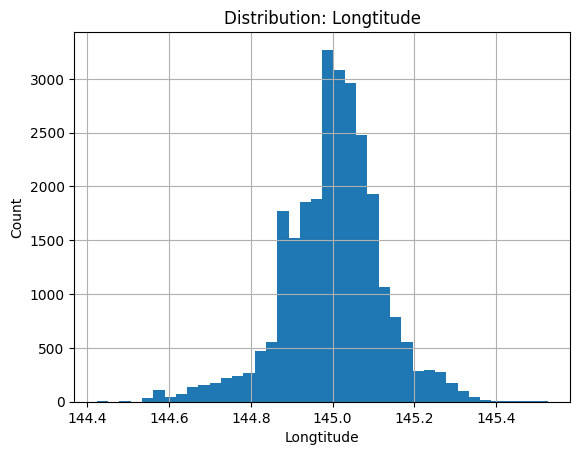


Plotting value counts for up to 8 categorical variables...


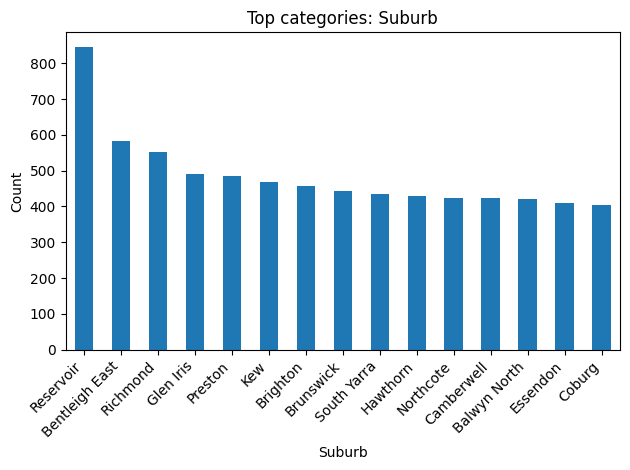

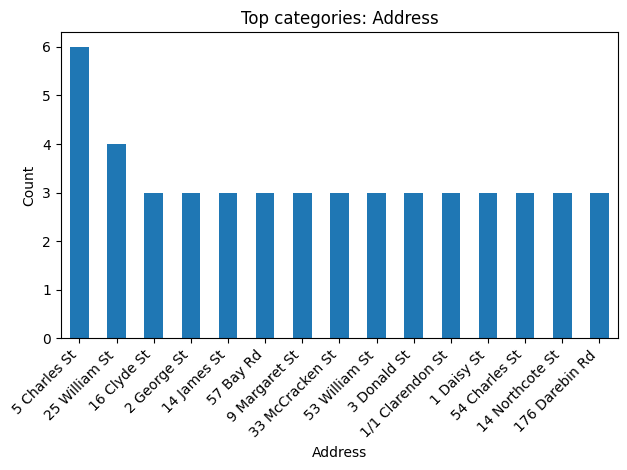

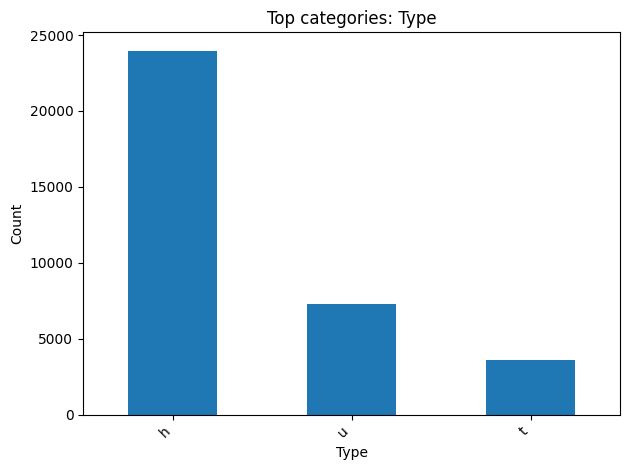

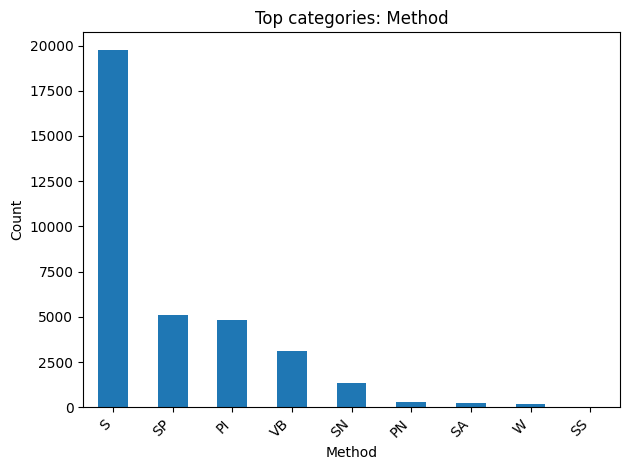

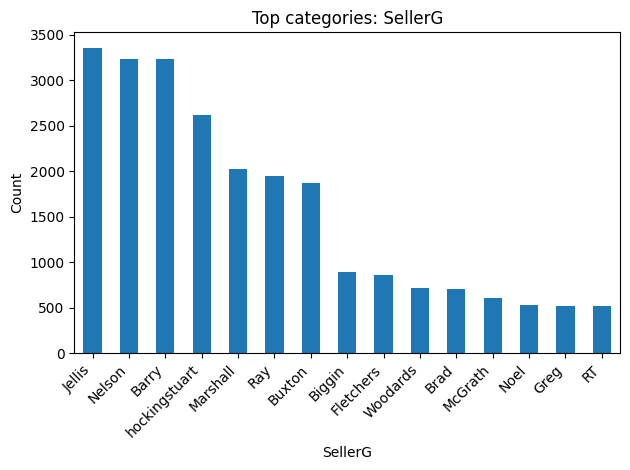

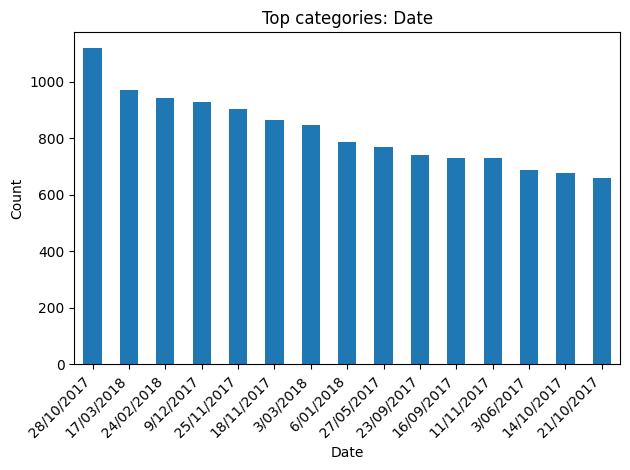

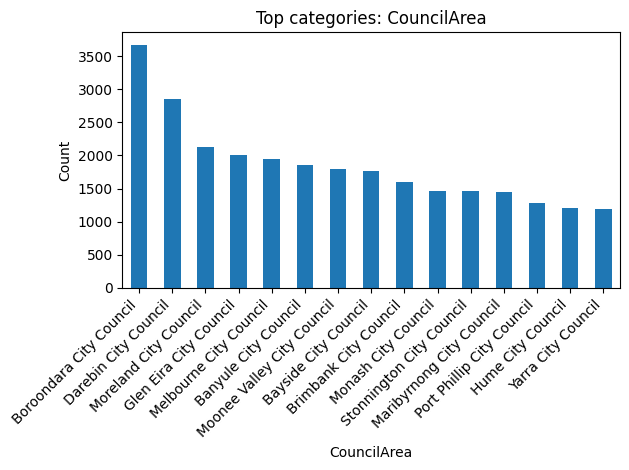

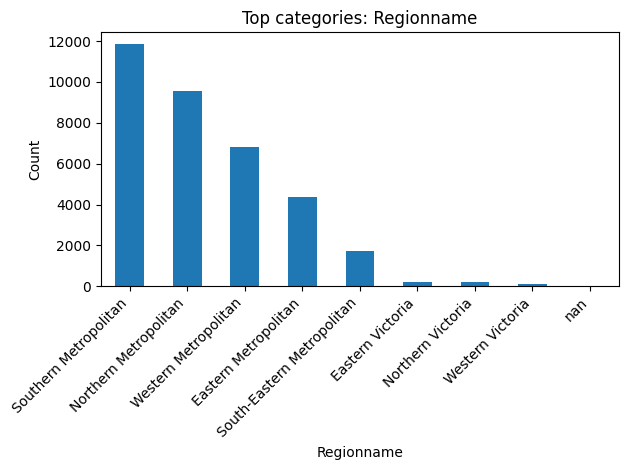

In [18]:
# 7) Univariate plots (overview)
# Numeric distributions (top K to avoid too many plots)
K = min(12, len(num_cols))
if K > 0:
    print(f"\nPlotting distributions for up to {K} numeric variables...")
    for col in num_cols[:K]:
        plt.figure()
        df[col].dropna().hist(bins=40)
        plt.title(f"Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

# Categorical counts (top K)
Kc = min(8, len(cat_cols))
if Kc > 0:
    print(f"\nPlotting value counts for up to {Kc} categorical variables...")
    for col in cat_cols[:Kc]:
        vc = df[col].value_counts(dropna=False).head(15)
        plt.figure()
        vc.plot(kind="bar")
        plt.title(f"Top categories: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()



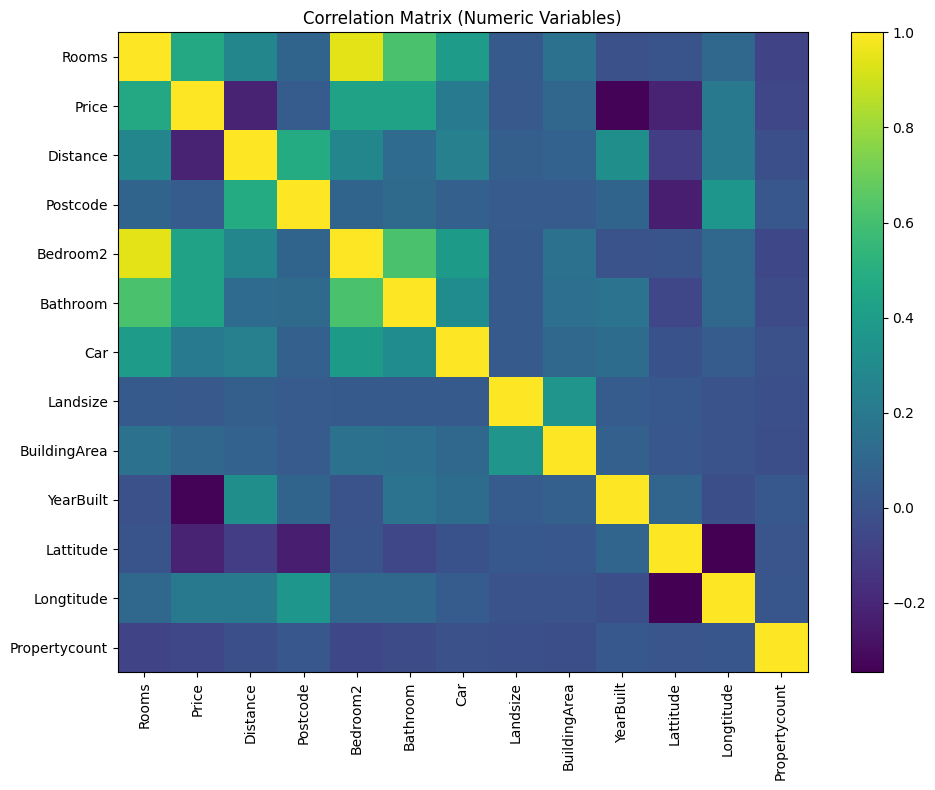

In [19]:
# 8) Correlation heatmap (numeric only)
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, aspect="auto")
    plt.title("Correlation Matrix (Numeric Variables)")
    plt.xticks(range(len(num_cols)), num_cols, rotation=90)
    plt.yticks(range(len(num_cols)), num_cols)
    plt.colorbar()
    plt.tight_layout()
    plt.show()



In [20]:
# 10) Lightweight "data dictionary" snapshot
data_dict = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(df[c].dtype) for c in df.columns],
    "missing_pct": [(df[c].isna().mean() * 100) for c in df.columns],
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
}).sort_values("missing_pct", ascending=False)

print("\nData dictionary snapshot (sorted by missing %):")
display(data_dict)



Data dictionary snapshot (sorted by missing %):


,column,dtype,missing_pct,n_unique
14,BuildingArea,float64,60.576068,740
15,YearBuilt,float64,55.386293,160
13,Landsize,float64,33.881286,1684
12,Car,float64,25.039447,15
11,Bathroom,float64,23.599277,11
10,Bedroom2,float64,23.573457,15
17,Lattitude,float64,22.882061,13402
18,Longtitude,float64,22.882061,14524
4,Price,float64,21.832057,2871
19,Regionname,object,0.008607,8


<a id="phase-1-data-engineering"></a>
## 4. Phase 1 — Data Engineering

<a id="missing-values"></a>
### 4.1 Missing Values

#### Missing values analysis:

In [21]:

print("MISSING VALUES ANALYSIS\n")

# Total missing values
missing_count = df.isna().sum()

# Percentage
missing_pct = (df.isna().sum() / len(df)) * 100

# Combine into one table
missing_table = pd.DataFrame({
    "Variable": df.columns,
    "Missing_Count": missing_count,
    "Missing_Percent": missing_pct
})

# Sort descending
missing_table = missing_table.sort_values(
    by="Missing_Percent", ascending=False
).reset_index(drop=True)

# Show only columns with missing values
missing_table_filtered = missing_table[missing_table["Missing_Count"] > 0]

print("Missing values per variable:")
display(missing_table_filtered)

print(f"\nTotal rows in dataset: {len(df)}")


MISSING VALUES ANALYSIS

Missing values per variable:


,Variable,Missing_Count,Missing_Percent
0,BuildingArea,21115,60.576068
1,YearBuilt,19306,55.386293
2,Landsize,11810,33.881286
3,Car,8728,25.039447
4,Bathroom,8226,23.599277
5,Bedroom2,8217,23.573457
6,Lattitude,7976,22.882061
7,Longtitude,7976,22.882061
8,Price,7610,21.832057
9,Regionname,3,0.008607



Total rows in dataset: 34857


#### Handling missing values by each variable:

##### Price:

In [22]:
# Check rows before
print("Rows before removing missing Price:", len(df))

# Remove missing target
df = df[df["Price"].notna()].copy()

# Check rows after
print("Rows after removing missing Price:", len(df))

# Verify
print("Remaining missing Price:", df["Price"].isna().sum())


Rows before removing missing Price: 34857
Rows after removing missing Price: 27247
Remaining missing Price: 0


Price is the target variable in this supervised learning problem. Observations with missing Price cannot be used for model training, as imputing the target would introduce artificial values and bias the model.

Therefore, all rows with missing Price were removed to ensure the integrity and validity of the predictive modeling process.

In [23]:
# ============================================================
# Missing Values Analysis AFTER removing missing Price
# ============================================================

print("Missing Values Analysis (After Removing Missing Price)\n")

# Count missing values
missing_count = df.isna().sum()

# Percentage missing
missing_percent = (df.isna().sum() / len(df)) * 100

# Combine into table
missing_table = pd.DataFrame({
    "Variable": df.columns,
    "Missing_Count": missing_count,
    "Missing_Percent": missing_percent
})

# Sort descending
missing_table = missing_table.sort_values(
    by="Missing_Percent", ascending=False
).reset_index(drop=True)

# Show only variables with missing values
missing_table_filtered = missing_table[missing_table["Missing_Count"] > 0]

display(missing_table_filtered)

# Global summary
print(f"\nTotal rows after removing missing Price: {len(df)}")
print(f"Total missing cells remaining: {df.isna().sum().sum():,}")
print(f"Percentage of dataset still missing: "
      f"{(df.isna().sum().sum() / (df.shape[0]*df.shape[1]) * 100):.2f}%")


Missing Values Analysis (After Removing Missing Price)



,Variable,Missing_Count,Missing_Percent
0,BuildingArea,16591,60.891107
1,YearBuilt,15163,55.650163
2,Landsize,9265,34.003744
3,Car,6824,25.044959
4,Bathroom,6447,23.661321
5,Bedroom2,6441,23.639300
6,Lattitude,6254,22.952986
7,Longtitude,6254,22.952986
8,Regionname,3,0.011010
9,Propertycount,3,0.011010



Total rows after removing missing Price: 27247
Total missing cells remaining: 73,250
Percentage of dataset still missing: 12.80%


##### Year Building:

In [24]:
# 1) Missing indicator
df["YearBuilt_missing"] = df["YearBuilt"].isna().astype(int) #We create a variable that tell us if we had or we ddint have the info of year built, with that we wont lose predictive power, knowing that is a 55% of the properties that didnt have this info.

# 2) Median imputation: we will fill all the missing values with the median
yearbuilt_median = df["YearBuilt"].median()
df["YearBuilt"] = df["YearBuilt"].fillna(yearbuilt_median)

print("YearBuilt median used:", yearbuilt_median)
print("Remaining missing YearBuilt:", df["YearBuilt"].isna().sum())
display(df[["YearBuilt", "YearBuilt_missing"]].head())


YearBuilt median used: 1970.0
Remaining missing YearBuilt: 0


,YearBuilt,YearBuilt_missing
1,1970.0,1
2,1900.0,0
4,1900.0,0
5,1970.0,1
6,2014.0,0


##### Land size:

In [25]:
df["Landsize_missing"] = df["Landsize"].isna().astype(int)

df["Landsize"] = df.groupby("Suburb")["Landsize"].transform(
    lambda x: x.fillna(x.median())
)

df["Landsize"] = df["Landsize"].fillna(df["Landsize"].median())

[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty sli

Landsize exhibited approximately 34 % missing values and a highly skewed distribution. A simple median imputation could artificially compress the variance and bias the relationship with price. Therefore, a hierarchical imputation strategy was applied: missing values were first imputed using the median Landsize within each suburb, preserving local geographic patterns, followed by global median imputation as a fallback. Additionally, a binary missing indicator was introduced to allow models to capture potential information contained in the absence of this feature.

##### Car, Bathroom y Bedroom2: 

In [26]:
# ============================================================
# Structural housing variables
# ============================================================

for col in ["Car", "Bathroom", "Bedroom2"]:
    
    # Missing indicator
    df[col + "_missing"] = df[col].isna().astype(int)
    
    # Median imputation
    df[col] = df[col].fillna(df[col].median())

print("Structural variables imputed.")

Structural variables imputed.


##### Lattitude y Longtitude: 

In [27]:
# ============================================================
# Geographic variables
# ============================================================

df["Lattitude"] = df.groupby("Suburb")["Lattitude"].transform(
    lambda x: x.fillna(x.median())
)

df["Longtitude"] = df.groupby("Suburb")["Longtitude"].transform(
    lambda x: x.fillna(x.median())
)

# Fallback in case any still missing
df["Lattitude"] = df["Lattitude"].fillna(df["Lattitude"].median())
df["Longtitude"] = df["Longtitude"].fillna(df["Longtitude"].median())

print("Geographic variables imputed.")

[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty sli

Geographic variables imputed.


[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
[local-path] RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


##### The remaining variables:

In [28]:
df["Regionname"] = df["Regionname"].fillna(df["Regionname"].mode()[0])
df["CouncilArea"] = df["CouncilArea"].fillna(df["CouncilArea"].mode()[0])

df["Propertycount"] = df["Propertycount"].fillna(df["Propertycount"].median())
df["Distance"] = df["Distance"].fillna(df["Distance"].median())
df["Postcode"] = df["Postcode"].fillna(df["Postcode"].median())

##### Building Area:

 Special Treatment for `BuildingArea`

The variable **`BuildingArea`** is one of the most important structural characteristics of a property, as it directly reflects the internal size of the dwelling and is therefore strongly related to housing prices. However, this variable also presents the **highest proportion of missing values in the dataset (around 60%)**, making its treatment particularly critical for the quality of the predictive models.

Because of both its **high predictive relevance** and **extensive missingness**, `BuildingArea` will receive a **dedicated imputation strategy** rather than a simple statistical replacement.

Two common approaches were considered but rejected:

**Row deletion.**  
Removing all observations with missing values in `BuildingArea` would eliminate more than half of the available observations. This would dramatically reduce the size of the dataset and consequently **reduce the predictive capacity of the models**, since a large portion of the information contained in the housing market data would be lost.

**Simple statistical imputation (mean or median).**  
Replacing approximately 60% of the observations with a single constant value would artificially compress the variance of the variable and distort its relationship with other important predictors such as price, number of rooms, or land size. This would lead to a significant **loss of useful information and predictive signal**.

For these reasons, a **model-based imputation strategy** will be used instead. In this approach, a machine learning model will be trained to estimate the missing values of `BuildingArea` using other structural and geographic characteristics of the properties.

However, before performing this imputation step, it is necessary to **detect and remove extreme outliers in the dataset**. The Melbourne Housing dataset contains several unrealistic or extreme values in variables such as building size and land size. These outliers can severely distort machine learning models by introducing unrealistic relationships between predictors and the target variable.

If the imputation model were trained in the presence of these extreme observations, it could learn inaccurate patterns and produce unreliable predictions. Therefore, the **outlier detection and mitigation stage (Section 4.2)** will be performed first. Once the dataset has been cleaned of extreme values, the model-based imputation for `BuildingArea` will be applied. This ensures that the imputed values are based on **realistic property characteristics and more stable statistical relationships**.

<a id="outliers"></a>
### 4.2 Outliers

In [29]:
print("Dataset shape:", df.shape)
print("\nColumns in dataset:")
print(df.columns.tolist())


Dataset shape: (27247, 26)

Columns in dataset:
['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG', 'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'YearBuilt_missing', 'Landsize_missing', 'Car_missing', 'Bathroom_missing', 'Bedroom2_missing']


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27247 entries, 1 to 34856
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Suburb             27247 non-null  object 
 1   Address            27247 non-null  object 
 2   Rooms              27247 non-null  int64  
 3   Type               27247 non-null  object 
 4   Price              27247 non-null  float64
 5   Method             27247 non-null  object 
 6   SellerG            27247 non-null  object 
 7   Date               27247 non-null  object 
 8   Distance           27247 non-null  float64
 9   Postcode           27247 non-null  float64
 10  Bedroom2           27247 non-null  float64
 11  Bathroom           27247 non-null  float64
 12  Car                27247 non-null  float64
 13  Landsize           27247 non-null  float64
 14  BuildingArea       10656 non-null  float64
 15  YearBuilt          27247 non-null  float64
 16  CouncilArea        27247 no

Numeric variables considered for outlier analysis:
['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount', 'YearBuilt_missing', 'Landsize_missing', 'Car_missing', 'Bathroom_missing', 'Bedroom2_missing']


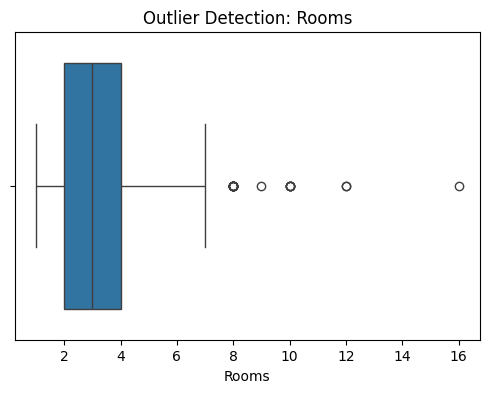

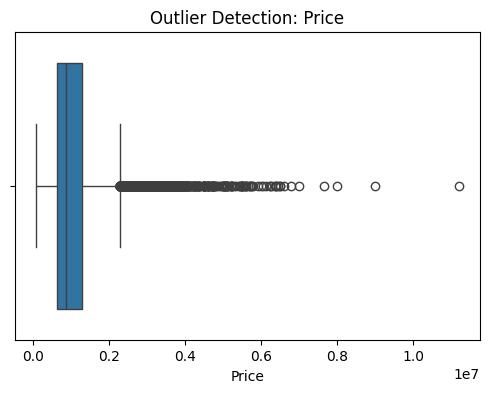

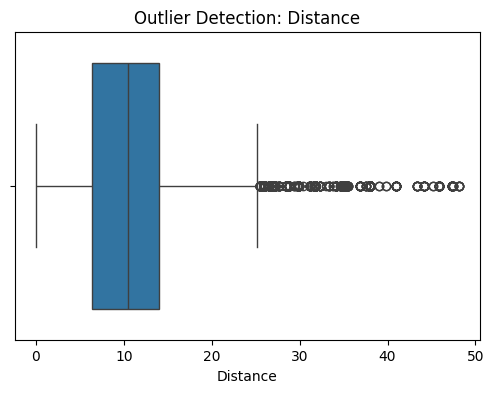

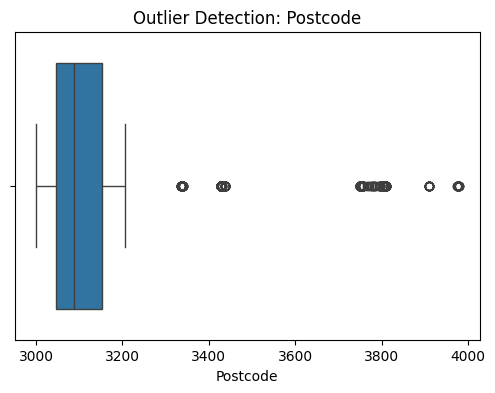

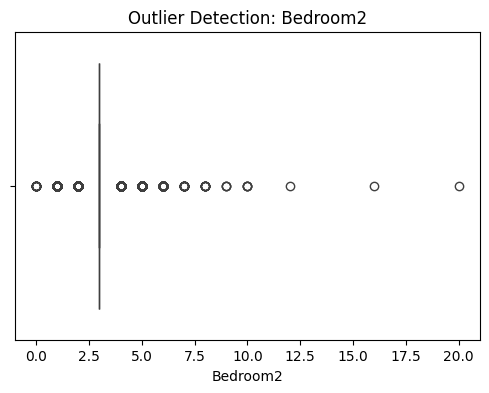

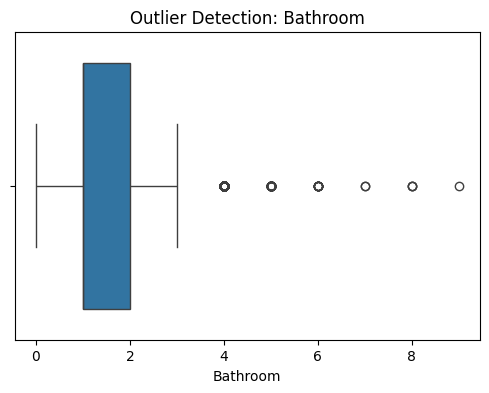

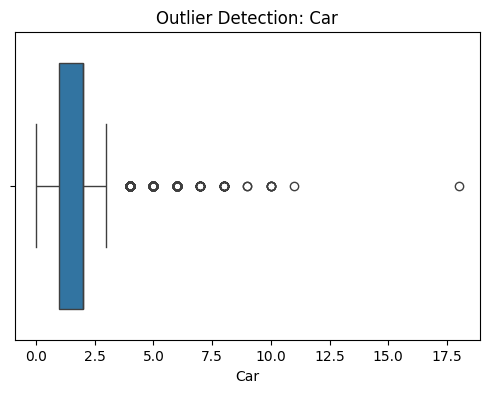

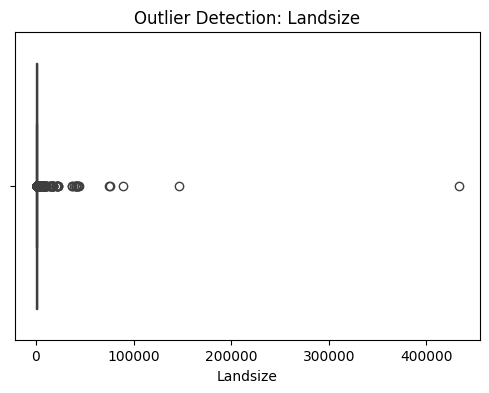

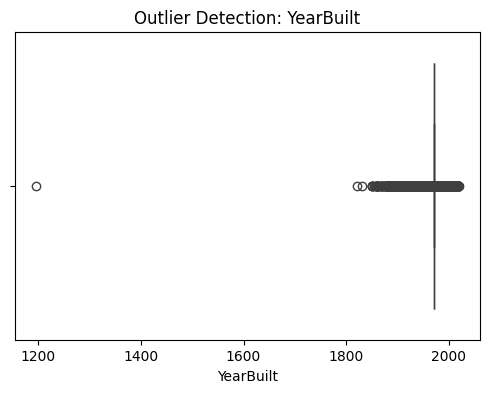

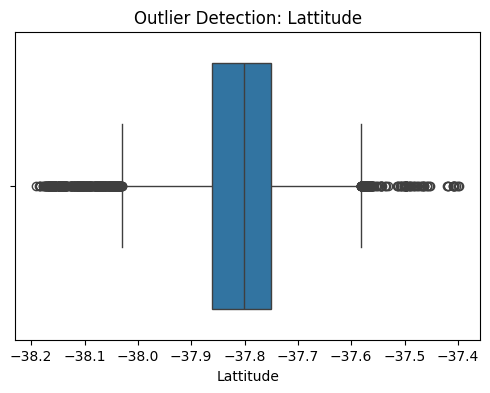

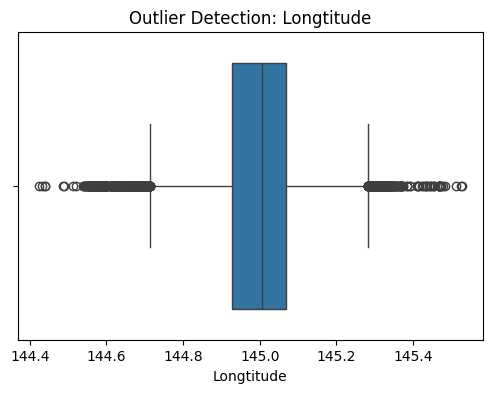

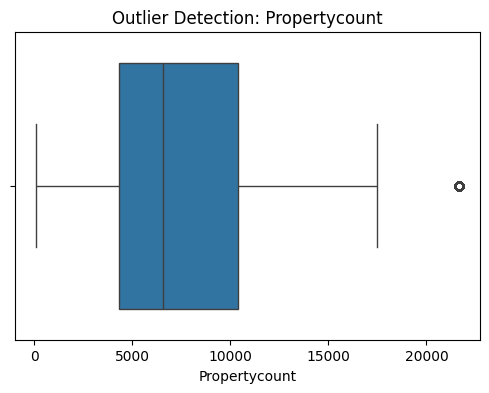

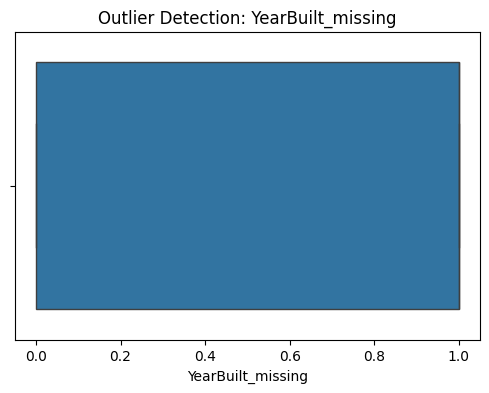

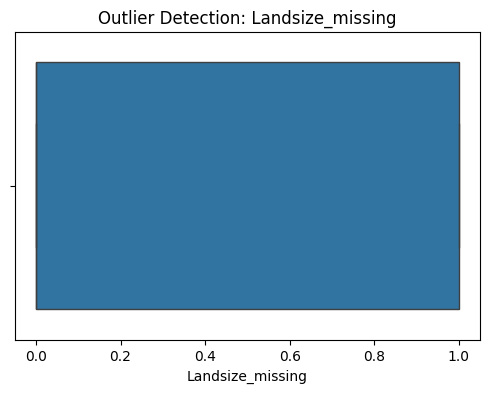

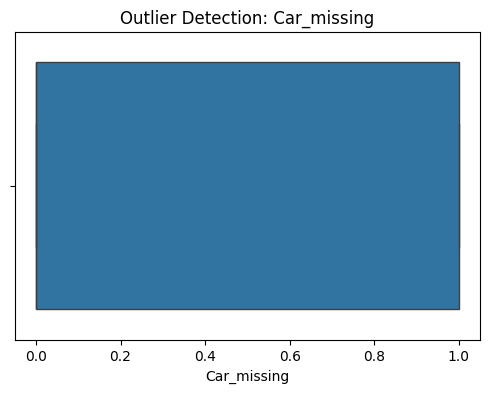

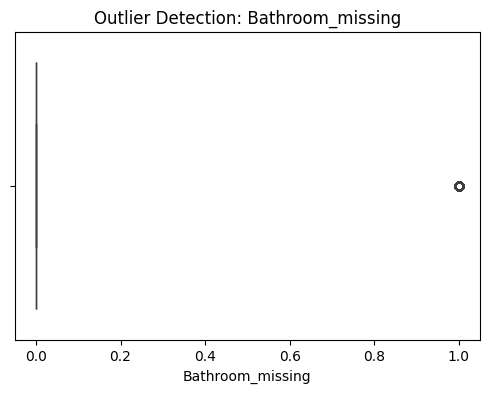

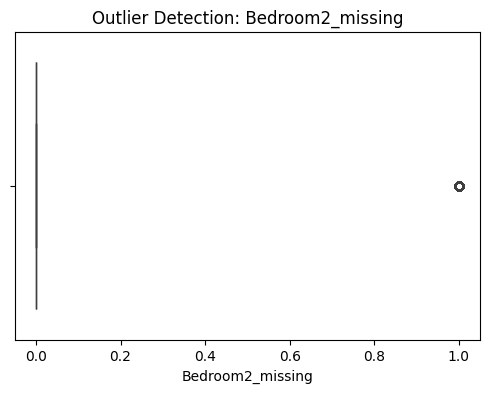

In [31]:
# ============================================================
# Outlier Analysis (Graphical Exploration)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Select numeric variables
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Remove BuildingArea from analysis for now
num_cols = [col for col in num_cols if col != "BuildingArea"]

print("Numeric variables considered for outlier analysis:")
print(num_cols)

# Plot boxplots
for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Outlier Detection: {col}")
    plt.xlabel(col)
    
    plt.show()

In [32]:
# Select numeric variables
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Remove BuildingArea and missing indicators
num_cols = [
    col for col in num_cols 
    if col != "BuildingArea" and not col.endswith("_missing")
]

print("Variables considered for outlier analysis:")
print(num_cols)

Variables considered for outlier analysis:
['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']


In [33]:
# ============================================================
# Numerical Outlier Detection using IQR
# ============================================================

import pandas as pd

outlier_summary = []

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    outlier_summary.append({
        "Variable": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": len(outliers),
        "Outlier_Percent": (len(outliers) / len(df)) * 100
    })

outlier_table = pd.DataFrame(outlier_summary).sort_values(
    by="Outlier_Percent", ascending=False
)

display(outlier_table)

,Variable,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
4,Bedroom2,3.00000,3.000000e+00,11390,41.802767
8,YearBuilt,1970.00000,1.970000e+03,10890,39.967703
1,Price,-355000.00000,2.285000e+06,1278,4.690425
2,Distance,-5.00000,2.540000e+01,1188,4.360113
6,Car,-0.50000,3.500000e+00,1171,4.297721
10,Longtitude,144.71335,1.452817e+02,944,3.464602
3,Postcode,2885.50000,3.313500e+03,794,2.914082
11,Propertycount,-4883.00000,1.958900e+04,727,2.668184
9,Lattitude,-38.02980,-3.758132e+01,672,2.466327
7,Landsize,-337.00000,1.231000e+03,538,1.974529


In [34]:
df[num_cols].describe(percentiles=[0.01,0.05,0.95,0.99])

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,YearBuilt,Lattitude,Longtitude,Propertycount
count,27247.000000,2.724700e+04,27247.000000,27247.000000,27247.000000,27247.000000,27247.000000,27247.000000,27247.000000,27247.000000,27247.000000,27247.000000
mean,2.992293,1.050173e+06,11.280247,3113.795133,3.035307,1.451683,1.786655,559.649833,1968.496165,-37.807815,144.997749,7566.671010
std,0.954795,6.414671e+05,6.787346,111.137746,0.834856,0.661993,0.869543,3085.139343,24.539477,0.090968,0.118115,4492.147337
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.190430,144.423790,83.000000
1%,1.000000,3.100000e+05,1.600000,3006.000000,1.000000,1.000000,0.000000,0.000000,1890.000000,-38.076003,144.655354,852.000000
5%,2.000000,4.150000e+05,2.700000,3015.000000,2.000000,1.000000,1.000000,0.000000,1913.000000,-37.950018,144.804590,2079.000000
50%,3.000000,8.700000e+05,10.500000,3088.000000,3.000000,1.000000,2.000000,534.000000,1970.000000,-37.801600,145.005400,6567.000000
95%,5.000000,2.250000e+06,24.700000,3204.000000,4.000000,3.000000,3.000000,873.700000,2010.000000,-37.674152,145.178385,15510.000000
99%,5.000000,3.400540e+06,35.400000,3754.000000,5.000000,3.000000,4.000000,2048.000000,2015.000000,-37.586593,145.286605,21650.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,20.000000,9.000000,18.000000,433014.000000,2019.000000,-37.397800,145.526350,21650.000000


In [35]:
# ============================================================
# Outlier mitigation using percentiles
# ============================================================

cols_outliers = ["Price", "Landsize", "Distance"]

for col in cols_outliers:
    
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Dataset shape after outlier removal:", df.shape)

Dataset shape after outlier removal: (26042, 26)


##### Selective Outlier Treatment

The numerical outlier analysis showed that the IQR rule flags extreme observations in several variables. However, not all detected outliers should be removed automatically. In real estate data, it is essential to distinguish between:

- **true extreme but valid market observations**, and  
- **observations that are likely to distort the statistical structure of the dataset**.

For this reason, outlier treatment was applied **selectively**, rather than uniformly across all variables.

#### Why not remove outliers from all variables?

Some variables such as **`Bedroom2`**, **`Bathroom`**, **`Car`**, **`Rooms`**, and **`YearBuilt`** are either **discrete structural features** or variables with highly concentrated distributions. In these cases, the IQR rule can mechanically classify many observations as outliers even when they are economically plausible.

For example:

- A property with **5 bedrooms**, **4 bathrooms**, or **4 parking spaces** may be uncommon, but it is still a realistic housing configuration.
- A property with an old or very recent **construction year** is not necessarily an error; it may simply reflect genuine variation in the housing stock.
- Because these variables take a limited number of repeated values, the IQR can become very narrow, making many legitimate observations appear as “outliers” even though they are not problematic.

Removing such observations would therefore risk deleting **valid heterogeneity in the housing market**, which is precisely the type of variation that predictive models should learn.

The same reasoning applies to **geographic variables** such as **`Lattitude`** and **`Longtitude`**. Extreme values in these variables often correspond to properties located in suburbs farther from the central urban area. These observations are not necessarily anomalies; instead, they represent the genuine spatial extent of the Melbourne housing market. Removing them would artificially compress the geographic coverage of the dataset and could bias any subsequent clustering or location-based prediction.

##### Why were `Price`, `Landsize`, and `Distance` treated?

Outlier mitigation was applied to **`Price`**, **`Landsize`**, and **`Distance`** because these variables are continuous, strongly skewed, and much more sensitive to extreme values.

These variables directly affect the structure of the predictive pipeline for several reasons:

1. **They are central to the economic interpretation of the dataset.**  
   `Price` is the target variable, while `Landsize` and `Distance` are major drivers of housing valuation.

2. **Extreme values in these variables can dominate the modeling process.**  
   Very large prices, very large land sizes, or unusually distant properties may exert disproportionate influence on scaling, clustering, dimensionality reduction, and prediction models.

3. **Some of these extreme observations are likely to reflect data-entry issues or rare transactions that are not representative of the broader market.**  
   In particular, variables such as `Landsize` often contain unrealistic values in housing datasets, and these can severely distort averages, variances, and fitted relationships.

4. **These variables are also used in later stages of the pipeline.**  
   Since the project requires PCA, clustering, and supervised models, leaving extreme continuous values untreated would risk distorting the entire hybrid modeling process.

##### Why use percentile trimming instead of deleting all IQR outliers?

Instead of removing all observations flagged by the IQR rule, a **percentile-based trimming approach** was preferred for these continuous variables. This is more appropriate in housing data because such variables often have naturally long right tails.

By trimming only the most extreme observations (for example, below the 1st percentile and above the 99th percentile), the dataset retains the vast majority of realistic market variation while reducing the influence of values that are excessively rare or potentially erroneous.

In summary, outlier treatment was not applied mechanically. It was based on the **economic meaning of each variable**, the **statistical behavior of its distribution**, and its **role in the downstream machine learning pipeline**. This selective strategy preserves meaningful market heterogeneity while reducing the distortion caused by extreme continuous observations.

#### Building Area treatment: 

In [36]:

# Model-Based Imputation for BuildingArea


from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Copy dataframe to avoid mistakes
df_impute = df.copy()

# 1. Create missing indicator
df_impute["BuildingArea_missing"] = df_impute["BuildingArea"].isna().astype(int)

# 2. Separate rows with and without BuildingArea
df_train = df_impute[df_impute["BuildingArea"].notna()]
df_missing = df_impute[df_impute["BuildingArea"].isna()]

print("Rows with BuildingArea:", len(df_train))
print("Rows missing BuildingArea:", len(df_missing))

# 3. Select predictive features
num_features = [
    "Rooms",
    "Bathroom",
    "Bedroom2",
    "Car",
    "Landsize",
    "Distance",
    "Propertycount",
    "Lattitude",
    "Longtitude"
]

cat_features = [
    "Type",
    "Regionname",
    "CouncilArea"
]

features = num_features + cat_features

# Remove rows where predictors are missing (for training)
df_train = df_train.dropna(subset=num_features)

# 4. Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# 5. Model
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

# 6. Train model
pipeline.fit(
    df_train[features],
    df_train["BuildingArea"]
)

print("Imputation model trained successfully.")

# 7. Predict missing values
predicted_values = pipeline.predict(df_missing[features])

# 8. Fill missing values
df_impute.loc[df_impute["BuildingArea"].isna(), "BuildingArea"] = predicted_values

print("Missing BuildingArea values imputed.")

# 9. Verify
print("\nRemaining missing BuildingArea:",
      df_impute["BuildingArea"].isna().sum())

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    df_train[features],
    df_train["BuildingArea"],
    test_size=0.2,
    random_state=42
)

# Train model
pipeline.fit(X_train, y_train)

# Predict validation set
y_pred = pipeline.predict(X_val)

# Metrics
r2 = r2_score(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)

print("Model performance for BuildingArea imputation:")
print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


Rows with BuildingArea: 10154
Rows missing BuildingArea: 15888
Imputation model trained successfully.
Missing BuildingArea values imputed.

Remaining missing BuildingArea: 0
Model performance for BuildingArea imputation:
R²: 0.076
RMSE: 205.87
MAE: 40.50


##### Evaluation of the BuildingArea Imputation Model

To assess the reliability of the model-based imputation strategy, the Random Forest model was evaluated using a validation split on the subset of observations where `BuildingArea` was available.

The model achieved an R² of approximately **0.076**, indicating that a modest but meaningful portion of the variance in building size can be explained by the available structural and geographic property characteristics.

The **Mean Absolute Error (MAE)** was approximately **40.5 square meters**, suggesting that the predictions capture the general magnitude of building sizes despite the inherent variability in property structures. The **Root Mean Squared Error (RMSE)** of about **206 square meters** indicates that some large deviations remain, which is expected in housing datasets where property sizes can vary widely.

Although the model does not perfectly predict the building area, it provides **substantially more informative estimates than simple statistical imputation methods**, such as replacing missing values with a single median value. By conditioning predictions on property characteristics and location, the model preserves the heterogeneity of the housing market and produces more realistic imputed values.

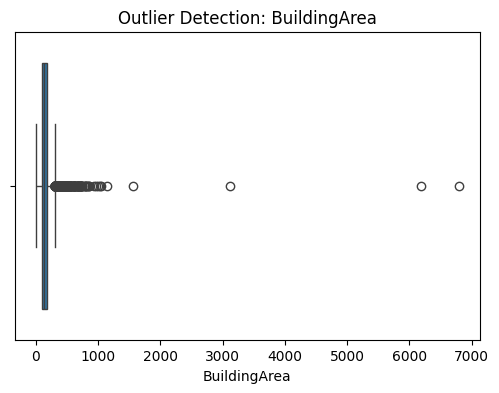

In [37]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["BuildingArea"])
plt.title("Outlier Detection: BuildingArea")
plt.show()

In [38]:
# ============================================================
# Count outliers in BuildingArea using percentile method
# ============================================================

# Calculate percentile thresholds
lower = df["BuildingArea"].quantile(0.01)
upper = df["BuildingArea"].quantile(0.99)

# Identify outliers
outliers = df[(df["BuildingArea"] < lower) | (df["BuildingArea"] > upper)]

# Count outliers
outlier_count = len(outliers)
outlier_percent = (outlier_count / len(df)) * 100

print("BuildingArea Outlier Analysis")
print("-----------------------------")
print("Lower bound (1%):", lower)
print("Upper bound (99%):", upper)
print("Number of outliers:", outlier_count)
print("Percentage of dataset:", round(outlier_percent,2), "%")

BuildingArea Outlier Analysis
-----------------------------
Lower bound (1%): 3.0
Upper bound (99%): 453.0
Number of outliers: 190
Percentage of dataset: 0.73 %


In [39]:
lower = df["BuildingArea"].quantile(0.01)
upper = df["BuildingArea"].quantile(0.99)

df = df[(df["BuildingArea"] >= lower) & (df["BuildingArea"] <= upper)]

print("Dataset shape after BuildingArea outlier removal:", df.shape)

Dataset shape after BuildingArea outlier removal: (9964, 26)


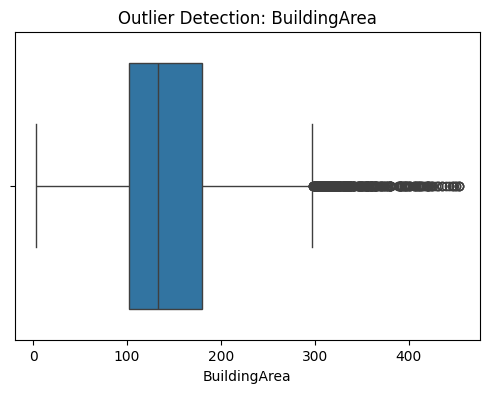

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["BuildingArea"])
plt.title("Outlier Detection: BuildingArea")
plt.show()

<a id="feature-engineering-preprocessing"></a>
### 4.3 Feature Engineering & Preprocessing

After handling missing values and mitigating extreme outliers, the dataset must be prepared for the modeling stages. Machine learning algorithms generally require numerical inputs and are often sensitive to the scale of the variables.

Therefore, the following preprocessing steps were applied:

1. Separation of numerical and categorical variables.
2. Encoding of categorical variables using one-hot encoding.
3. Standardization of numerical variables to ensure comparable scales across features.

These transformations ensure that the dataset is suitable for dimensionality reduction, clustering, and predictive modeling in the subsequent phases of the project.

In [41]:
# Remove high-cardinality / identifier variables
drop_cols = ["Address", "SellerG", "Date", "Method"]

df = df.drop(columns=drop_cols)

print("New dataset shape:", df.shape)
print("\nRemaining columns:")
print(df.columns.tolist())

New dataset shape: (9964, 22)

Remaining columns:
['Suburb', 'Rooms', 'Type', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude', 'Longtitude', 'Regionname', 'Propertycount', 'YearBuilt_missing', 'Landsize_missing', 'Car_missing', 'Bathroom_missing', 'Bedroom2_missing']


In [42]:
# Target variable
y = df["Price"]

# Features
X = df.drop(columns=["Price"])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (9964, 21)
Target shape: (9964,)


In [43]:
# Numerical variables
num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Categorical variables
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", num_features)
print("Categorical features:", cat_features)

Numerical features: ['Rooms', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount', 'YearBuilt_missing', 'Landsize_missing', 'Car_missing', 'Bathroom_missing', 'Bedroom2_missing']
Categorical features: ['Suburb', 'Type', 'CouncilArea', 'Regionname']


##### Preprocessing pipeline:

In [44]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)


In [45]:
X_processed = preprocessor.fit_transform(X)

print("Processed dataset shape:", X_processed.shape)

Processed dataset shape: (9964, 359)


##### Excluding the Target Variable from Unsupervised Learning

The variable `Price` represents the target variable of the predictive task in Phase 3. For this reason, it was excluded from the unsupervised learning stage.

Including the target variable in PCA or clustering would introduce target leakage, as the unsupervised features would indirectly encode information about the variable that the models are later asked to predict.

Instead, the unsupervised analysis is performed using only property characteristics such as structural attributes, geographic location, and neighborhood indicators. The resulting latent features (principal components and cluster labels) are then appended to the dataset and later used as additional predictors in the supervised modeling stage.

#### Convertir la matriz transformada a un DataFrame

In [46]:
import pandas as pd

X_processed_df = pd.DataFrame(
    X_processed.toarray(),
    columns=preprocessor.get_feature_names_out()
)

print(X_processed_df.shape)
display(X_processed_df.head())

(9964, 359)


,num__Rooms,num__Distance,num__Postcode,num__Bedroom2,num__Bathroom,num__Car,num__Landsize,num__BuildingArea,num__YearBuilt,num__Lattitude,...,cat__CouncilArea_Yarra City Council,cat__CouncilArea_Yarra Ranges Shire Council,cat__Regionname_Eastern Metropolitan,cat__Regionname_Eastern Victoria,cat__Regionname_Northern Metropolitan,cat__Regionname_Northern Victoria,cat__Regionname_South-Eastern Metropolitan,cat__Regionname_Southern Metropolitan,cat__Regionname_Western Metropolitan,cat__Regionname_Western Victoria
0,-1.198965,-1.370197,-0.390515,-1.173301,-0.934242,-1.807748,-1.029989,-1.002858,-1.797101,-0.074189,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.117443,-1.370197,-0.390515,-0.096704,0.513920,-1.807748,-1.107629,0.047604,-1.797101,-0.090206,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.964078,-1.370197,-0.390515,-0.096704,-0.934242,0.311857,-1.157037,-0.070758,1.301512,-0.066180,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.117443,-1.370197,-0.390515,0.979894,0.513920,-1.807748,-0.715898,0.935318,-1.525293,-0.011263,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-1.198965,-1.370197,-0.390515,-1.173301,-0.934242,0.311857,-0.677078,-0.588592,-2.068909,-0.052451,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [47]:
X_processed = preprocessor.fit_transform(X)

print("Processed dataset shape:", X_processed.shape)

X_processed_df = pd.DataFrame(
    X_processed.toarray(),
    columns=preprocessor.get_feature_names_out()
)

print("Processed DataFrame shape:", X_processed_df.shape)

Processed dataset shape: (9964, 359)
Processed DataFrame shape: (9964, 359)


<a id="final-analysis-ready-dataset"></a>
### 4.4 Final Analysis-Ready Dataset


After completing the data engineering steps, the dataset is now prepared for the modeling stages of the project. 

The preprocessing pipeline addressed several key issues present in the raw dataset:

- Missing values were handled using a combination of statistical and model-based imputation strategies.
- Extreme outliers were detected and mitigated to prevent unrealistic observations from distorting the analysis.
- High-cardinality identifier variables were removed to avoid unnecessary dimensional expansion.
- Categorical variables were encoded and numerical variables were standardized to produce a fully numerical feature matrix.

As a result, the dataset is now clean, consistent, and ready for the unsupervised learning stage where latent market structures will be explored.

In [48]:
print("Final dataset shape:", X_processed_df.shape)

Final dataset shape: (9964, 359)


In [49]:
print("Remaining missing values:", X_processed_df.isna().sum().sum())

Remaining missing values: 0


In [50]:
display(X_processed_df.head())

,num__Rooms,num__Distance,num__Postcode,num__Bedroom2,num__Bathroom,num__Car,num__Landsize,num__BuildingArea,num__YearBuilt,num__Lattitude,...,cat__CouncilArea_Yarra City Council,cat__CouncilArea_Yarra Ranges Shire Council,cat__Regionname_Eastern Metropolitan,cat__Regionname_Eastern Victoria,cat__Regionname_Northern Metropolitan,cat__Regionname_Northern Victoria,cat__Regionname_South-Eastern Metropolitan,cat__Regionname_Southern Metropolitan,cat__Regionname_Western Metropolitan,cat__Regionname_Western Victoria
0,-1.198965,-1.370197,-0.390515,-1.173301,-0.934242,-1.807748,-1.029989,-1.002858,-1.797101,-0.074189,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,-0.117443,-1.370197,-0.390515,-0.096704,0.513920,-1.807748,-1.107629,0.047604,-1.797101,-0.090206,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.964078,-1.370197,-0.390515,-0.096704,-0.934242,0.311857,-1.157037,-0.070758,1.301512,-0.066180,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,-0.117443,-1.370197,-0.390515,0.979894,0.513920,-1.807748,-0.715898,0.935318,-1.525293,-0.011263,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,-1.198965,-1.370197,-0.390515,-1.173301,-0.934242,0.311857,-0.677078,-0.588592,-2.068909,-0.052451,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [51]:
X_processed_df.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
num__Rooms,9964.0,-1.483269e-16,1.00005,-2.280487,-0.117443,-0.117443,0.964078,9.616251
num__Distance,9964.0,-2.510147e-16,1.00005,-1.510983,-0.744483,-0.118769,0.463927,3.745016
num__Postcode,9964.0,1.118156e-15,1.00005,-0.963272,-0.587133,-0.262286,0.319020,7.388724
num__Bedroom2,9964.0,6.845855e-17,1.00005,-3.326496,-0.096704,-0.096704,0.979894,9.592672
num__Bathroom,9964.0,7.986831e-17,1.00005,-0.934242,-0.934242,0.513920,0.513920,9.202897
num__Car,9964.0,1.140976e-16,1.00005,-1.807748,-0.747946,0.311857,0.311857,8.790276
num__Landsize,9964.0,4.563904e-17,1.00005,-1.580530,-0.811184,0.122265,0.671041,5.594148
num__BuildingArea,9964.0,-1.369171e-16,1.00005,-2.127296,-0.670335,-0.203915,0.491461,4.530560
num__YearBuilt,9964.0,1.665825e-15,1.00005,-20.932394,-0.438060,0.105556,0.920981,1.437416
num__Lattitude,9964.0,-6.234292e-14,1.00005,-3.933262,-0.643954,0.055096,0.635787,3.054258



After completing the data engineering and preprocessing steps, the dataset is now fully prepared for the modeling stages of the project. The final processed dataset contains **9,964 observations and 359 engineered features**, representing a structured and machine-learning-ready version of the Melbourne housing market data.

Several key characteristics of the processed dataset can be observed from the summary statistics:

First, the numerical variables have been **standardized using a StandardScaler**, which centers each variable around zero and rescales it to have unit variance. This transformation is visible in the table above, where the mean of each numerical variable is approximately **0** and the standard deviation is approximately **1**. Standardization ensures that all variables contribute comparably to distance-based algorithms such as PCA and clustering, preventing variables with larger scales from dominating the analysis.

Second, the distribution statistics reveal meaningful variation across the housing attributes. Variables such as **Rooms**, **Bedroom2**, **Bathroom**, and **Car** show relatively concentrated interquartile ranges, reflecting typical structural characteristics of residential properties in the dataset. Meanwhile, variables such as **Landsize** and **BuildingArea** exhibit larger spreads between their lower and upper quartiles, indicating greater heterogeneity in property sizes. This variation is expected in real estate data and is an important source of information for both segmentation and price prediction.

Third, the standardized ranges also highlight the presence of properties that differ substantially from the typical housing profile. For instance, some standardized values exceed 3 or 4 standard deviations from the mean, reflecting larger homes or properties located farther from the city center. Because the most extreme outliers were previously removed during the outlier mitigation stage, these remaining values likely represent legitimate market variation rather than data errors.

Finally, the dataset now consists entirely of **numerical features**, including both standardized continuous variables and one-hot encoded categorical variables. The categorical information from variables such as **Suburb, Type, CouncilArea, and Regionname** has been transformed into binary indicators, allowing machine learning algorithms to incorporate geographic and structural market differences without introducing ordinal assumptions.

Overall, the resulting dataset is **clean, numerically consistent, and suitable for advanced modeling techniques**. Its standardized structure is particularly appropriate for the next stage of the project, where dimensionality reduction and clustering methods will be applied to uncover latent patterns and market segments within the Melbourne housing market.

<a id="phase-2-unsupervised-feature-discovery"></a>
## 5. Phase 2 — Unsupervised Feature Discovery

<a id="dimensionality-reduction-pca"></a>
### 5.1 Dimensionality Reduction (PCA)

After preprocessing, the dataset contains 359 numerical features. While this representation preserves the full information from the original dataset, such high dimensionality can complicate interpretation and affect the performance of clustering algorithms.

To uncover the main directions of variation in the Melbourne housing market, **Principal Component Analysis (PCA)** is applied. PCA transforms the original feature space into a smaller set of orthogonal components that summarize the dominant patterns in the data.

This dimensionality reduction serves two main objectives:

1. To create a compact representation of the dataset for clustering and market segmentation.
2. To generate latent features that may improve predictive performance when included in supervised models.

The first step is to evaluate how much variance is explained as the number of components increases.

In [52]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Fit PCA on processed dataset
pca_full = PCA()
pca_full.fit(X_processed_df)

# Cumulative explained variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

print("Total components:", len(cum_var))

Total components: 359


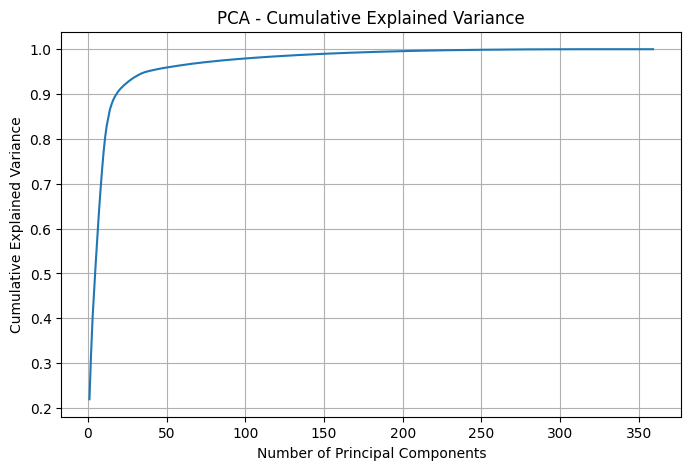

In [53]:
plt.figure(figsize=(8,5))

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.grid(True)

plt.show()

In [54]:
thresholds = [0.80, 0.85, 0.90, 0.95]

for t in thresholds:
    n_comp = np.argmax(cum_var >= t) + 1
    print(f"Components needed for {int(t*100)}% variance: {n_comp}")

Components needed for 80% variance: 11
Components needed for 85% variance: 14
Components needed for 90% variance: 19
Components needed for 95% variance: 38


In [55]:
from sklearn.decomposition import PCA

# Final PCA with 90% variance
pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X_processed_df)

print("Original features:", X_processed_df.shape[1])
print("PCA components:", X_pca.shape[1])

Original features: 359
PCA components: 19


In [56]:
pca_columns = [f"PC{i+1}" for i in range(X_pca.shape[1])]

pca_df = pd.DataFrame(X_pca, columns=pca_columns)

display(pca_df.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
0,-3.184089,-0.376572,-1.464907,0.189395,-0.198301,-0.604894,0.330865,0.609732,-1.338651,-0.011535,0.209557,0.024445,0.398800,0.228810,0.697308,-0.291107,0.201561,-0.040935,-0.002924
1,-1.289212,-0.881404,-2.032136,-0.480729,0.204033,-0.192609,0.013786,0.477969,-1.895470,-0.118971,0.197795,0.009432,0.676081,0.170168,0.701528,-0.212905,-0.009233,-0.126243,-0.063071
2,-0.495086,-0.720306,-0.147196,-0.932483,-0.305389,-0.011433,-0.362747,-0.521180,-0.074038,0.920553,0.406618,-1.170936,-1.443681,0.012549,0.861436,-0.609890,0.548979,-0.280453,-0.071892
3,-0.293249,-1.099602,-2.082367,-0.581276,0.303045,-0.211737,-0.030539,0.535089,-2.016997,-0.088718,-0.082432,0.104282,0.118556,0.438341,0.734380,-0.221271,-0.167127,-0.155885,-0.089288
4,-2.349083,-0.562472,-1.451159,0.739837,-0.344149,-0.595499,0.468090,0.413108,0.039964,0.517921,1.394217,0.190742,0.394445,0.528288,0.679457,-0.278007,0.002647,-0.042519,0.035902


The PCA results show that a relatively small number of components is sufficient to explain most of the variance in the dataset. In particular, 19 principal components are enough to capture approximately 90% of the total variance.

This indicates that the high-dimensional feature space created during preprocessing contains substantial redundancy, and that the underlying structure of the data can be represented in a much lower-dimensional space.

A threshold of 90% explained variance was selected as it provides a balance between dimensionality reduction and information retention. While lower thresholds (e.g., 80% or 85%) would reduce the dimensionality further, they risk discarding important information. On the other hand, higher thresholds (e.g., 95%) would retain more variance but at the cost of keeping a larger number of components, which may negatively affect clustering performance.

The resulting principal components provide a compact and informative representation of the Melbourne housing market and will be used in the clustering stage to identify latent market segments.

The strong dimensionality reduction observed suggests that many of the original features are highly correlated, particularly those derived from one-hot encoding and property characteristics. PCA effectively captures these relationships and summarizes them into a smaller set of latent variables.

<a id="clustering-market-segmentation"></a>
### 5.2 Clustering & Market Segmentation

After reducing the dimensionality of the dataset using PCA, clustering techniques are applied to identify distinct segments within the Melbourne housing market.

Clustering allows us to group properties based on similarities in their characteristics without using the target variable (Price). This enables the discovery of latent market structures, such as differences between central and suburban properties, property types, and housing density patterns.

The clustering analysis is performed on the PCA-transformed dataset to ensure that noise and redundancy from the original high-dimensional feature space do not distort the segmentation results.

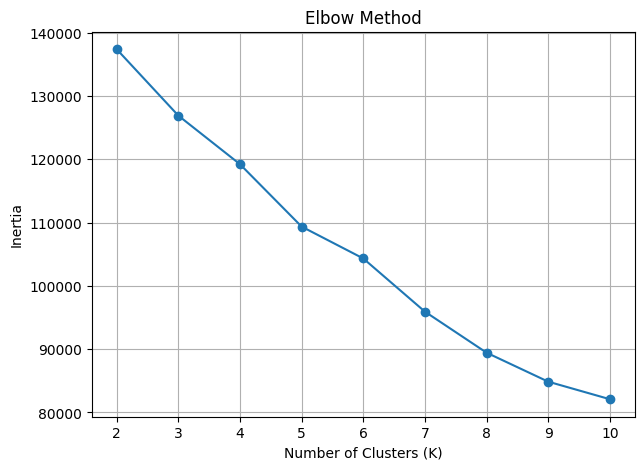

In [57]:

##Elbow method
from sklearn.cluster import KMeans

inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_df)
    inertia.append(kmeans.inertia_)

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

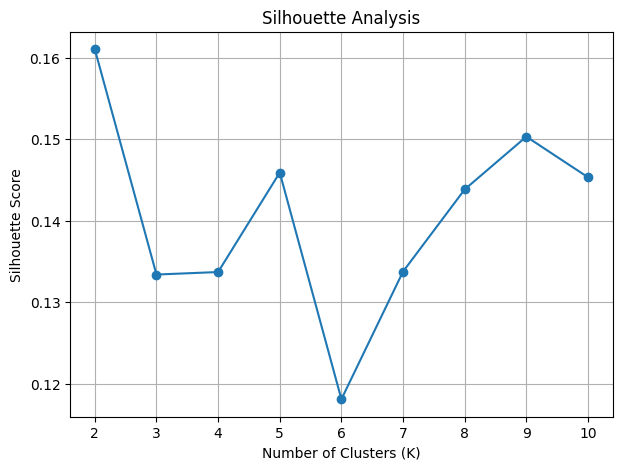

In [58]:
## silhouete score
from sklearn.metrics import silhouette_score

sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(pca_df)
    score = silhouette_score(pca_df, labels)
    sil_scores.append(score)

# Plot
plt.figure(figsize=(7,5))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.grid(True)
plt.show()

##### Choosing the Number of Clusters

To determine the optimal number of clusters, both the Elbow Method and the Silhouette Score were analyzed.

The Elbow Method shows a clear inflection point around **K = 5**, where the reduction in inertia begins to slow down significantly. This suggests that adding more clusters beyond this point yields diminishing returns in terms of compactness.

The Silhouette analysis indicates that the highest score occurs at K = 2. However, this is expected, as clustering into only two groups often produces artificially high separation without capturing meaningful market structure. More informative solutions are found for values between K = 4 and K = 9, where the silhouette scores remain relatively stable.

Considering both criteria, **K = 5** was selected as it provides a good balance between cluster compactness and interpretability. This choice allows for a more detailed segmentation of the housing market without introducing unnecessary complexity.

In [59]:
##K MEANS

from sklearn.cluster import KMeans

# Define model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit and predict clusters
clusters = kmeans.fit_predict(pca_df)

# Add cluster labels to PCA dataset
pca_df["Cluster"] = clusters

# Quick check
print("Cluster distribution:")
print(pca_df["Cluster"].value_counts())

Cluster distribution:
Cluster
0    3293
3    3292
2    2864
4     344
1     171
Name: count, dtype: int64


In [60]:
# Copy original dataset
df_final = df.copy()

# Add cluster labels
df_final["Cluster"] = clusters

display(df_final.head())

,Suburb,Rooms,Type,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,...,Lattitude,Longtitude,Regionname,Propertycount,YearBuilt_missing,Landsize_missing,Car_missing,Bathroom_missing,Bedroom2_missing,Cluster
2,Abbotsford,2,h,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,...,-37.8079,144.9934,Northern Metropolitan,4019.0,0,0,0,0,0,3
4,Abbotsford,3,h,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,...,-37.8093,144.9944,Northern Metropolitan,4019.0,0,0,0,0,0,3
6,Abbotsford,4,h,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,...,-37.8072,144.9941,Northern Metropolitan,4019.0,0,0,0,0,0,0
11,Abbotsford,3,h,1876000.0,2.5,3067.0,4.0,2.0,0.0,245.0,...,-37.8024,144.9993,Northern Metropolitan,4019.0,0,0,0,0,0,0
14,Abbotsford,2,h,1636000.0,2.5,3067.0,2.0,1.0,2.0,256.0,...,-37.8060,144.9954,Northern Metropolitan,4019.0,0,0,0,0,0,3


In [61]:
# Cluster summary (numeric variables)
cluster_summary = df_final.groupby("Cluster").mean(numeric_only=True)

display(cluster_summary)

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,YearBuilt_missing,Landsize_missing,Car_missing,Bathroom_missing,Bedroom2_missing
Cluster,,,,,,,,,,,,,,,,,,
0,3.372305,9.008753e+05,11.595870,3045.944124,3.352262,1.669602,1.935317,506.599302,152.590557,1972.226237,-37.748621,144.908000,7359.042818,0.029153,0.124810,0.0,0.0,0.0
1,2.883041,1.224712e+06,7.353216,3106.333333,2.883041,1.380117,2.000000,304.728070,122.824561,1923.239766,-37.809830,144.957597,7180.959064,0.040936,0.222222,1.0,0.0,0.0
2,3.781425,1.512260e+06,13.676013,3142.998953,3.764316,2.116620,2.111732,622.893156,198.042700,1967.420740,-37.859538,145.093821,6741.375698,0.032821,0.134777,0.0,0.0,0.0
3,2.225699,8.727637e+05,7.213700,3101.854192,2.203827,1.199575,1.071081,229.213548,95.343542,1958.175577,-37.814140,144.990059,8068.590219,0.035541,0.083840,0.0,0.0,0.0
4,3.543605,5.780386e+05,28.572674,3605.901163,3.543605,1.880814,2.055233,591.723837,168.581366,1994.078488,-37.696938,144.924040,7752.904070,0.061047,0.250000,0.0,0.0,0.0


In [62]:
cluster_sizes = df_final["Cluster"].value_counts().sort_index()

print("Cluster sizes:")
print(cluster_sizes)

Cluster sizes:
Cluster
0    3293
1     171
2    2864
3    3292
4     344
Name: count, dtype: int64


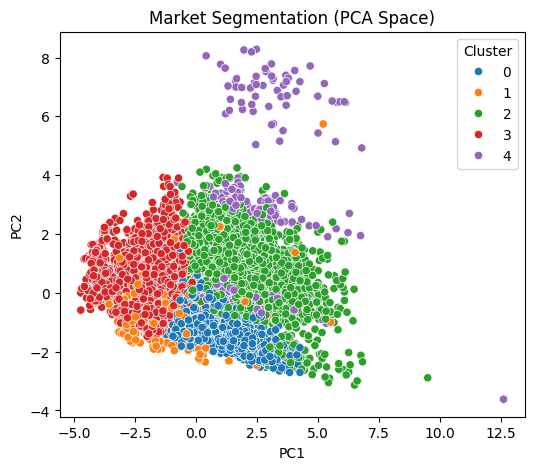

In [63]:
## CLUSTER VISUALIZATION
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"],
    hue=pca_df["Cluster"],
    palette="tab10"
)

plt.title("Market Segmentation (PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

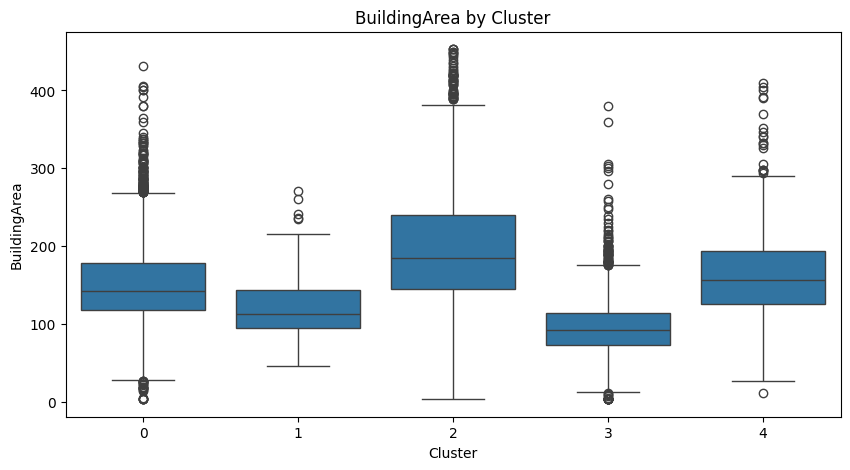

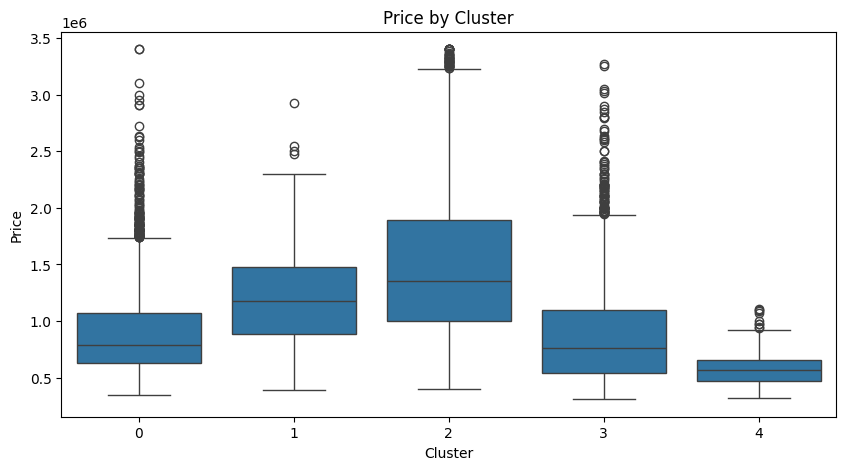

In [64]:
##Boxplot por cluster:

plt.figure(figsize=(10,5))
sns.boxplot(x="Cluster", y="BuildingArea", data=df_final)
plt.title("BuildingArea by Cluster")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x="Cluster", y="Price", data=df_final)
plt.title("Price by Cluster")
plt.show()

#### Clustering Results

Using the selected value of K = 5, the K-Means algorithm was applied to the PCA-transformed dataset. Each observation was assigned to one of five clusters representing different segments of the Melbourne housing market.

The resulting clusters vary in size and characteristics, indicating heterogeneity in property types, locations, and structural features. These clusters provide a meaningful segmentation of the market, which will be further analyzed to understand the underlying patterns and economic interpretation of each group.

The cluster labels are also appended to the original dataset, allowing them to be used as additional features in the predictive modeling stage.

#### In-Depth Interpretation of Market Segments

The clustering results reveal a rich and economically meaningful segmentation of the Melbourne housing market. Each cluster captures a distinct combination of structural, geographic, and neighborhood characteristics, reflecting underlying trade-offs faced by households in the housing market.

A key pattern that emerges across clusters is the classic **price–location–space trade-off**, which is central in urban economics. Households must balance proximity to the city center, property size, and affordability, and each cluster reflects a different equilibrium of these factors.

#### Cluster 0 — Balanced Suburban Housing

Cluster 0 represents **mid-sized suburban family homes** that strike a balance between space, location, and price. These properties have moderate building areas, relatively large land sizes, and are located at an intermediate distance from the city center.

This segment likely corresponds to typical suburban households that prioritize both living space and accessibility, without paying the premium associated with central locations. It reflects a “middle-market” equilibrium where households optimize across multiple dimensions rather than specializing in one.


#### Cluster 1 — Central, Older, High-Value Properties

Cluster 1 captures **older properties located closer to the city center**, with relatively smaller sizes but significantly higher prices. The average construction year suggests established neighborhoods, and the proximity to the center indicates strong location value.

This segment illustrates the importance of **location-driven pricing**: even though these properties are smaller and older, their centrality leads to higher prices. This is consistent with urban economic theory, where land closer to economic activity hubs commands a premium due to reduced commuting costs and higher accessibility.


#### Cluster 2 — Premium Large Suburban Homes

Cluster 2 represents **high-end suburban properties** with the largest building areas, largest land sizes, and the highest number of rooms, bathrooms, and parking spaces. These properties also exhibit the highest average prices in the dataset.

Despite being located farther from the city center, their strong structural characteristics place them in the premium segment of the market. This cluster reflects households that prioritize **space, comfort, and housing quality over proximity**, often trading longer commuting distances for better living conditions.


#### Cluster 3 — Compact Urban Properties

Cluster 3 corresponds to **smaller and more compact properties located relatively close to the city center**. These homes have fewer rooms, smaller building areas, and limited parking capacity.

This segment likely represents apartments or compact housing units in denser urban areas. It reflects households that prioritize **location and accessibility over space**, often due to lifestyle preferences or budget constraints. These properties may appeal to younger households, professionals, or individuals seeking proximity to employment centers.


#### Cluster 4 — Peripheral and Affordable Housing

Cluster 4 clearly represents **outer suburban properties**, characterized by the greatest distance from the city center, relatively recent construction, and lower average prices despite having large land and building areas.

This cluster highlights the role of **geographic peripherality in reducing housing prices**. Even though these properties offer more space, their distance from economic centers makes them more affordable. This segment likely corresponds to expanding suburban developments where land is cheaper and housing supply is more abundant.


#### Implications for Predictive Modeling

The identified clusters provide a powerful new feature for the supervised learning stage. Since they summarize complex interactions between location, size, and structural characteristics, they can help predictive models capture non-linear relationships that are not easily modeled using raw variables alone.

This demonstrates the value of integrating unsupervised learning into the predictive pipeline, as required by the project’s “Hybrid Analysis” objective.

<a id="the-bridge-augmented-dataset"></a>
### 5.3 The Bridge: Augmented Dataset


The final step of the unsupervised learning phase consists of integrating the newly discovered latent features into the original dataset. This step creates the "bridge" between Phase 2 and Phase 3 of the project.

Two types of features are added:

- **Principal Components (PCs)** obtained from PCA, which summarize the main directions of variation in the dataset.
- **Cluster labels**, which represent the market segments identified through clustering.

By augmenting the dataset with these features, we allow supervised learning models to leverage both the original variables and the latent structures discovered during the unsupervised analysis.

This hybrid approach is expected to improve predictive performance by capturing complex, non-linear relationships that are not directly observable in the raw data.

In [65]:
# Reset index to avoid alignment issues
df_reset = df.reset_index(drop=True)
pca_df_reset = pca_df.reset_index(drop=True)

In [66]:
# Add PCA components
df_augmented = pd.concat([df_reset, pca_df_reset.drop(columns=["Cluster"])], axis=1)
# Add cluster label
df_augmented["Cluster"] = pca_df_reset["Cluster"]


In [67]:
print("Augmented dataset shape:", df_augmented.shape)

display(df_augmented.head())

Augmented dataset shape: (9964, 42)


,Suburb,Rooms,Type,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,...,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,Cluster
0,Abbotsford,2,h,1035000.0,2.5,3067.0,2.0,1.0,0.0,156.0,...,0.209557,0.024445,0.398800,0.228810,0.697308,-0.291107,0.201561,-0.040935,-0.002924,3
1,Abbotsford,3,h,1465000.0,2.5,3067.0,3.0,2.0,0.0,134.0,...,0.197795,0.009432,0.676081,0.170168,0.701528,-0.212905,-0.009233,-0.126243,-0.063071,3
2,Abbotsford,4,h,1600000.0,2.5,3067.0,3.0,1.0,2.0,120.0,...,0.406618,-1.170936,-1.443681,0.012549,0.861436,-0.609890,0.548979,-0.280453,-0.071892,0
3,Abbotsford,3,h,1876000.0,2.5,3067.0,4.0,2.0,0.0,245.0,...,-0.082432,0.104282,0.118556,0.438341,0.734380,-0.221271,-0.167127,-0.155885,-0.089288,0
4,Abbotsford,2,h,1636000.0,2.5,3067.0,2.0,1.0,2.0,256.0,...,1.394217,0.190742,0.394445,0.528288,0.679457,-0.278007,0.002647,-0.042519,0.035902,3


The augmented dataset now combines both the original property characteristics and the latent features discovered through unsupervised learning.

The principal components provide a compact representation of the underlying structure of the data, capturing correlations and interactions among variables. At the same time, the cluster labels encode market segmentation, grouping properties into economically meaningful categories.

This enriched feature space allows the predictive models in the next phase to incorporate both detailed input variables and higher-level abstractions of the housing market, improving their ability to model complex patterns in property prices.

Dataset A → without PCA or Cluster (baseline)

Dataset B → with PCA + Cluster (augmented)

<a id="phase-3-model-tournament-a-vs-b"></a>
## 6. Phase 3 — Model Tournament (A vs B)

<a id="evaluation-design-metrics"></a>
### 6.1 Evaluation Design & Metrics

To evaluate the performance of the predictive models, a consistent and rigorous evaluation framework is established.

The objective is to predict the continuous target variable `Price`, which makes this a regression problem. Therefore, multiple performance metrics are used to capture different aspects of model accuracy.

In addition, two datasets are defined in order to assess the impact of the unsupervised learning stage:

- **Dataset A (Baseline):** uses only the original features.
- **Dataset B (Augmented):** includes both the original features and the features derived from PCA and clustering.

By comparing model performance across these two datasets, we can evaluate whether the unsupervised feature engineering step improves predictive accuracy.

In [68]:
## metrics:

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

Three evaluation metrics are used:

- **RMSE (Root Mean Squared Error):** penalizes large errors more heavily and provides a measure of overall prediction accuracy.
- **MAE (Mean Absolute Error):** measures the average magnitude of prediction errors in a more robust way, less sensitive to outliers.
- **R² (Coefficient of Determination):** indicates the proportion of variance in the target variable explained by the model.

Using multiple metrics ensures a comprehensive evaluation of model performance.

In [69]:
### we check if the dataset has just numbers or also characters

X_A = X_processed_df.copy()
X_B = pd.concat([
    X_processed_df.reset_index(drop=True),
    pca_df.drop(columns=["Cluster"]).reset_index(drop=True),
    pca_df["Cluster"].reset_index(drop=True)
], axis=1)

### Target

y = df["Price"]

### Train Test split

from sklearn.model_selection import train_test_split

X_A_train, X_A_test, y_train, y_test = train_test_split(
    X_A, y, test_size=0.2, random_state=42
)

X_B_train, X_B_test, _, _ = train_test_split(
    X_B, y, test_size=0.2, random_state=42
)

print("Train size:", X_A_train.shape)
print("Test size:", X_A_test.shape)

Train size: (7971, 359)
Test size: (1993, 359)


The dataset is split into training and testing sets using an 80/20 split. The same split is applied to both Dataset A and Dataset B to ensure a fair comparison between models.

The training set is used to fit the models, while the test set is used to evaluate their performance on unseen data. This approach helps assess the generalization ability of each model and prevents overfitting.

<a id="baseline-linear-regularized-regression"></a>
### 6.2 Baseline: Linear / Regularized Regression

As a baseline model, linear regression and its regularized variants are used to establish a reference level of predictive performance.

Linear models provide a simple and interpretable framework for prediction. However, due to the high dimensionality and potential multicollinearity introduced by one-hot encoding, regularized models such as Ridge and Lasso regression are also considered.

These models help control overfitting and improve generalization by penalizing large coefficients.

The baseline models are trained on both Dataset A (original features) and Dataset B (augmented with PCA and clustering features) to assess the contribution of the unsupervised learning stage.

#### Linear regression dataset A

In [70]:
from sklearn.linear_model import LinearRegression

# Train
lr = LinearRegression()
lr.fit(X_A_train, y_train)

# Predict
y_pred_lr = lr.predict(X_A_test)

# Evaluate
results_lr = evaluate_model(y_test, y_pred_lr)

print("Linear Regression (Baseline A):")
print(results_lr)

Linear Regression (Baseline A):
{'RMSE': np.float64(263624.5258135031), 'MAE': 188264.82287108776, 'R2': 0.7795167609565329}


#### Ridge Regression dataset A

In [71]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning
ridge = Ridge()

param_grid = {
    "alpha": [0.1, 1, 10, 50, 100]
}

ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring="neg_mean_squared_error")

ridge_cv.fit(X_A_train, y_train)

# Best model
ridge_best = ridge_cv.best_estimator_

# Predict
y_pred_ridge = ridge_best.predict(X_A_test)

# Evaluate
results_ridge = evaluate_model(y_test, y_pred_ridge)

print("Ridge Regression (Baseline A):")
print(results_ridge)
print("Best alpha:", ridge_cv.best_params_)

Ridge Regression (Baseline A):
{'RMSE': np.float64(263272.48987745005), 'MAE': 187695.5750144707, 'R2': 0.7801052206141645}
Best alpha: {'alpha': 1}


#### Lasso Regression dataset A

In [72]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring="neg_mean_squared_error")

lasso_cv.fit(X_A_train, y_train)

# Best model
lasso_best = lasso_cv.best_estimator_

# Predict
y_pred_lasso = lasso_best.predict(X_A_test)

# Evaluate
results_lasso = evaluate_model(y_test, y_pred_lasso)

print("Lasso Regression (Baseline A):")
print(results_lasso)
print("Best alpha:", lasso_cv.best_params_)

[local-path] ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.053e+14, tolerance: 2.081e+11
  model = cd_fast.enet_coordinate_descent(
[local-path] ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.047e+14, tolerance: 2.030e+11
  model = cd_fast.enet_coordinate_descent(
[local-path] ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.070e+14, tolerance: 2.135e+11
  model = cd_fast.enet_coordinate_descent(
[local-path] ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

Lasso Regression (Baseline A):
{'RMSE': np.float64(263370.4560726676), 'MAE': 187820.10783333448, 'R2': 0.77994154029243}
Best alpha: {'alpha': 10}


#### Linear Regression dataset B

In [73]:
from sklearn.linear_model import LinearRegression

lr_B = LinearRegression()
lr_B.fit(X_B_train, y_train)

y_pred_lr_B = lr_B.predict(X_B_test)

results_lr_B = evaluate_model(y_test, y_pred_lr_B)

print("Linear Regression (Dataset B):")
print(results_lr_B)

Linear Regression (Dataset B):
{'RMSE': np.float64(263626.78011665447), 'MAE': 188267.77696185093, 'R2': 0.7795129901527035}


#### Ridge Regression dataset B

In [74]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

param_grid = {
    "alpha": [0.1, 1, 10, 50, 100]
}

ridge_cv_B = GridSearchCV(ridge, param_grid, cv=5, scoring="neg_mean_squared_error")

ridge_cv_B.fit(X_B_train, y_train)

ridge_best_B = ridge_cv_B.best_estimator_

y_pred_ridge_B = ridge_best_B.predict(X_B_test)

results_ridge_B = evaluate_model(y_test, y_pred_ridge_B)

print("Ridge Regression (Dataset B):")
print(results_ridge_B)
print("Best alpha:", ridge_cv_B.best_params_)

Ridge Regression (Dataset B):
{'RMSE': np.float64(263262.5288593534), 'MAE': 187680.1349685593, 'R2': 0.7801218599101349}
Best alpha: {'alpha': 1}


#### Lasso Regression dataset B

In [75]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

param_grid = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_cv_B = GridSearchCV(lasso, param_grid, cv=5, scoring="neg_mean_squared_error")

lasso_cv_B.fit(X_B_train, y_train)

lasso_best_B = lasso_cv_B.best_estimator_

y_pred_lasso_B = lasso_best_B.predict(X_B_test)

results_lasso_B = evaluate_model(y_test, y_pred_lasso_B)

print("Lasso Regression (Dataset B):")
print(results_lasso_B)
print("Best alpha:", lasso_cv_B.best_params_)

[local-path] ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.302e+14, tolerance: 2.081e+11
  model = cd_fast.enet_coordinate_descent(
[local-path] ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.238e+14, tolerance: 2.030e+11
  model = cd_fast.enet_coordinate_descent(
[local-path] ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.221e+14, tolerance: 2.135e+11
  model = cd_fast.enet_coordinate_descent(
[local-path] ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

Lasso Regression (Dataset B):
{'RMSE': np.float64(263371.11375927867), 'MAE': 187822.69512557847, 'R2': 0.7799404412345822}
Best alpha: {'alpha': 10}


[local-path] ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.481e+13, tolerance: 2.584e+11
  model = cd_fast.enet_coordinate_descent(


In [76]:
comparison_baseline = pd.DataFrame([
    {"Model": "Linear A", **results_lr},
    {"Model": "Ridge A", **results_ridge},
    {"Model": "Lasso A", **results_lasso},
    
    {"Model": "Linear B", **results_lr_B},
    {"Model": "Ridge B", **results_ridge_B},
    {"Model": "Lasso B", **results_lasso_B}
])

display(comparison_baseline)

,Model,RMSE,MAE,R2
0,Linear A,263624.525814,188264.822871,0.779517
1,Ridge A,263272.489877,187695.575014,0.780105
2,Lasso A,263370.456073,187820.107833,0.779942
3,Linear B,263626.780117,188267.776962,0.779513
4,Ridge B,263262.528859,187680.134969,0.780122
5,Lasso B,263371.113759,187822.695126,0.779940


#### Baseline Model Comparison

The baseline results show that all three linear models (Linear Regression, Ridge, and Lasso) achieve similar levels of performance, with an R² of approximately 0.78. This indicates that a substantial portion of the variation in housing prices can already be explained using a linear combination of the original features.

Regularization slightly improves performance, with Ridge regression achieving the best results among the baseline models. This suggests the presence of multicollinearity in the dataset, which is expected given the large number of features created through one-hot encoding.

When comparing Dataset A (original features) and Dataset B (augmented with PCA and clustering features), the results show **no significant improvement in predictive performance**. This outcome can be explained by the nature of the models used.

First, PCA is a linear transformation of the original variables. Since linear regression models already operate in a linear space, the principal components do not introduce fundamentally new information, but rather reorganize existing information.

Second, the cluster labels capture non-linear structure in the data, but linear models are limited in their ability to exploit such patterns. As a result, the additional features from Phase 2 do not translate into improved performance in this setting.

This finding is important, as it suggests that the value of the unsupervised feature engineering step may only become apparent when using more flexible, non-linear models. This hypothesis will be tested in the next section using ensemble methods.

<a id="ensemble-hyperparameter-optimization"></a>
### 6.3 Ensemble: Hyperparameter Optimization


To evaluate whether more flexible non-linear models can improve predictive performance, three ensemble approaches are tested on Dataset A:

- **Random Forest**, which reduces variance by averaging many decision trees;
- **Gradient Boosting**, which builds trees sequentially to correct previous errors;
- **XGBoost**, a more advanced boosting algorithm with regularization and strong predictive performance.

These models are expected to outperform linear baselines because housing prices are likely driven by non-linear relationships and interactions between structural and geographic characteristics.

#### Random forest and Grid search for dataset A

In [77]:
### model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [78]:
## Grid search

rf_cv_A = GridSearchCV(
    rf,
    param_grid,
    cv=3,  # más rápido, suficiente
    scoring="neg_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

rf_cv_A.fit(X_A_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [79]:
## Best Model

rf_best_A = rf_cv_A.best_estimator_

print("Best parameters (A):", rf_cv_A.best_params_)

## Prediction

y_pred_rf_A = rf_best_A.predict(X_A_test)

## Evaluation of results

results_rf_A = evaluate_model(y_test, y_pred_rf_A)

print("Random Forest (Dataset A):")
print(results_rf_A)

Best parameters (A): {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest (Dataset A):
{'RMSE': np.float64(217299.7727104711), 'MAE': 141265.97103302035, 'R2': 0.8501963133878733}


#### Gradient Boosting for dataset A

In [80]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

gbr = GradientBoostingRegressor(random_state=42)

param_grid_gbr = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "subsample": [0.8, 1.0]
}

gbr_cv_A = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

gbr_cv_A.fit(X_A_train, y_train)

gbr_best_A = gbr_cv_A.best_estimator_

y_pred_gbr_A = gbr_best_A.predict(X_A_test)

results_gbr_A = evaluate_model(y_test, y_pred_gbr_A)

print("Gradient Boosting (Dataset A):")
print(results_gbr_A)
print("Best parameters:", gbr_cv_A.best_params_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Gradient Boosting (Dataset A):
{'RMSE': np.float64(204146.74119946398), 'MAE': 136209.11343991396, 'R2': 0.8677825245518609}
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}


#### XGboost dataset A

In [81]:
# XGBoost is installed with the project requirements before running the notebook.


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [82]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

param_grid_xgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

xgb_cv_A = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid_xgb,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_cv_A.fit(X_A_train, y_train)

xgb_best_A = xgb_cv_A.best_estimator_

y_pred_xgb_A = xgb_best_A.predict(X_A_test)

results_xgb_A = evaluate_model(y_test, y_pred_xgb_A)

print("XGBoost (Dataset A):")
print(results_xgb_A)
print("Best parameters:", xgb_cv_A.best_params_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
XGBoost (Dataset A):
{'RMSE': np.float64(199788.20186844247), 'MAE': 132417.15413321625, 'R2': 0.8733679511744664}
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


#### Random Forest Dataset B

In [83]:
param_grid_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [84]:
rf_cv_B = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

rf_cv_B.fit(X_B_train, y_train)

rf_best_B = rf_cv_B.best_estimator_

y_pred_rf_B = rf_best_B.predict(X_B_test)

results_rf_B = evaluate_model(y_test, y_pred_rf_B)

print("Random Forest (Dataset B):")
print(results_rf_B)
print("Best params:", rf_cv_B.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Random Forest (Dataset B):
{'RMSE': np.float64(223790.51524511067), 'MAE': 147923.48152354668, 'R2': 0.841113386148953}
Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


#### Gradient Boosting dataset B

In [85]:
gbr_cv_B = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gbr,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

gbr_cv_B.fit(X_B_train, y_train)

gbr_best_B = gbr_cv_B.best_estimator_

y_pred_gbr_B = gbr_best_B.predict(X_B_test)

results_gbr_B = evaluate_model(y_test, y_pred_gbr_B)

print("Gradient Boosting (Dataset B):")
print(results_gbr_B)
print("Best params:", gbr_cv_B.best_params_)

Fitting 3 folds for each of 64 candidates, totalling 192 fits
Gradient Boosting (Dataset B):
{'RMSE': np.float64(209278.24968780956), 'MAE': 138224.75023596978, 'R2': 0.8610520492589038}
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200, 'subsample': 0.8}


#### XGBoost dataset B

In [86]:
xgb_cv_B = GridSearchCV(
    XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
    param_grid_xgb,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

xgb_cv_B.fit(X_B_train, y_train)

xgb_best_B = xgb_cv_B.best_estimator_

y_pred_xgb_B = xgb_best_B.predict(X_B_test)

results_xgb_B = evaluate_model(y_test, y_pred_xgb_B)

print("XGBoost (Dataset B):")
print(results_xgb_B)
print("Best params:", xgb_cv_B.best_params_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
XGBoost (Dataset B):
{'RMSE': np.float64(209556.15879733392), 'MAE': 139272.72517875064, 'R2': 0.8606827749509599}
Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


#### Final comparision:

In [87]:
final_comparison = pd.DataFrame([
    # Dataset A
    {"Model": "Random Forest A", **results_rf_A},
    {"Model": "Gradient Boosting A", **results_gbr_A},
    {"Model": "XGBoost A", **results_xgb_A},
    
    # Dataset B
    {"Model": "Random Forest B", **results_rf_B},
    {"Model": "Gradient Boosting B", **results_gbr_B},
    {"Model": "XGBoost B", **results_xgb_B}
])

display(final_comparison)

,Model,RMSE,MAE,R2
0,Random Forest A,217299.772710,141265.971033,0.850196
1,Gradient Boosting A,204146.741199,136209.113440,0.867783
2,XGBoost A,199788.201868,132417.154133,0.873368
3,Random Forest B,223790.515245,147923.481524,0.841113
4,Gradient Boosting B,209278.249688,138224.750236,0.861052
5,XGBoost B,209556.158797,139272.725179,0.860683


#### Ensemble Model Comparison — Dataset A vs Dataset B

The ensemble models show a clear and consistent pattern: Dataset A (original features) outperforms Dataset B (augmented with PCA and clustering features) across all models.

XGBoost achieves the best overall performance with an R² of approximately 0.873, confirming that non-linear models are better suited for capturing the complexity of housing prices.

However, the addition of PCA components and cluster labels does not improve performance. In fact, it leads to a slight degradation in all cases. This suggests that the engineered features from Phase 2 do not provide additional predictive value in this context.

There are several possible explanations for this result. First, PCA is a linear transformation that compresses information, which may lead to a loss of important feature-specific signals that tree-based models can exploit directly. Second, clustering simplifies the data structure by grouping observations, but this may reduce the granularity needed for accurate predictions.

Finally, ensemble models such as Random Forest and XGBoost are already capable of capturing complex non-linear relationships and interactions between variables. As a result, the additional features may be redundant or even introduce noise.

These findings highlight an important insight: the effectiveness of unsupervised feature engineering depends on the modeling approach. While such techniques can be useful in some contexts, they do not universally improve predictive performance.

<a id="deep-learner-ann-learning-curves"></a>
### 6.4 Deep Learner: ANN + Learning Curves

In this block we will train a neural network regressor using scikit-learn on both Dataset A and Dataset B, evaluates both models, plots the training loss curves, and builds a final comparison table including the three ensemble models plus the ANN for both datasets.

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [89]:
# 1. Evaluation function

# This function computes the three regression metrics used hroughout the project: RMSE, MAE, and R².
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"RMSE": rmse, "MAE": mae, "R2": r2}

In [90]:
# 2. Define the neural network model and hyperparameter grid

mlp = MLPRegressor(
    random_state=42,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=15
)

param_grid_mlp = {
    "hidden_layer_sizes": [(128, 64), (128, 64, 32), (64, 32)],
    "alpha": [0.0001, 0.001, 0.01],          # L2 regularization
    "learning_rate_init": [0.001, 0.01]
}


In [91]:

# 3. Train ANN on Dataset A

# Dataset A contains the original processed features only.
mlp_cv_A = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

mlp_cv_A.fit(X_A_train, y_train)

mlp_best_A = mlp_cv_A.best_estimator_
y_pred_mlp_A = mlp_best_A.predict(X_A_test)
results_mlp_A = evaluate_model(y_test, y_pred_mlp_A)

print("Neural Network (Dataset A):")
print(results_mlp_A)
print("Best params A:", mlp_cv_A.best_params_)


Fitting 3 folds for each of 18 candidates, totalling 54 fits
Neural Network (Dataset A):
{'RMSE': np.float64(223147.2360547168), 'MAE': 147285.36097395993, 'R2': 0.8420255030421129}
Best params A: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}


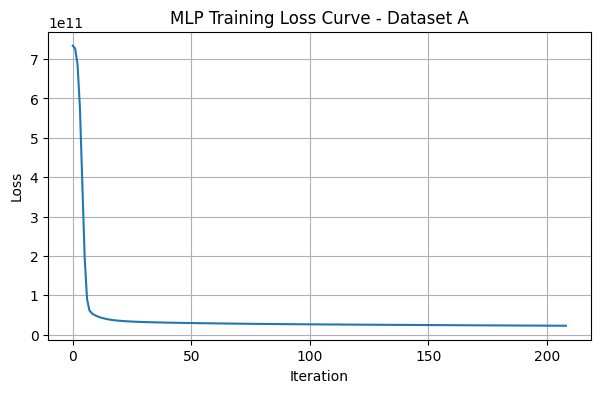

In [92]:
# 4. Plot training loss curve for Dataset A
# MLPRegressor stores the loss at each iteration in loss_curve_.

plt.figure(figsize=(7, 4))
plt.plot(mlp_best_A.loss_curve_)
plt.title("MLP Training Loss Curve - Dataset A")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [93]:
# 5. Train ANN on Dataset B
# # Dataset B contains the original processed features plus
# PCA components and the cluster label.
mlp_cv_B = GridSearchCV(
    estimator=mlp,
    param_grid=param_grid_mlp,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

mlp_cv_B.fit(X_B_train, y_train)

mlp_best_B = mlp_cv_B.best_estimator_
y_pred_mlp_B = mlp_best_B.predict(X_B_test)
results_mlp_B = evaluate_model(y_test, y_pred_mlp_B)

print("Neural Network (Dataset B):")
print(results_mlp_B)
print("Best params B:", mlp_cv_B.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Neural Network (Dataset B):
{'RMSE': np.float64(219519.04624237918), 'MAE': 146136.17677356172, 'R2': 0.8471208105571901}
Best params B: {'alpha': 0.01, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.01}


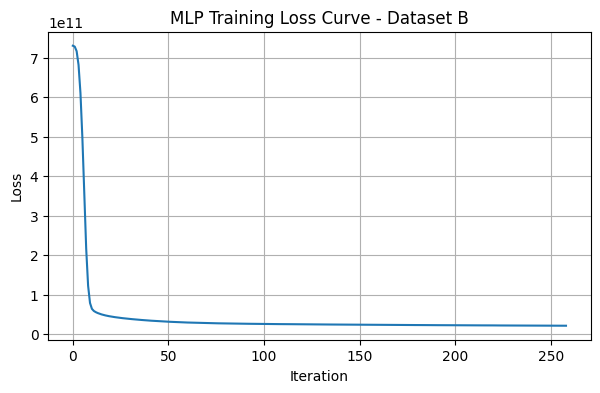

In [94]:
# 6. Plot training loss curve for Dataset B
plt.figure(figsize=(7, 4))
plt.plot(mlp_best_B.loss_curve_)
plt.title("MLP Training Loss Curve - Dataset B")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


#### Final Comparision table:

In [95]:

# 7. Final comparison table: 6 ensemble models + 2 ANN models

final_non_linear_comparison = pd.DataFrame([
    {"Model": "Random Forest A",      **results_rf_A},
    {"Model": "Gradient Boosting A",  **results_gbr_A},
    {"Model": "XGBoost A",            **results_xgb_A},
    {"Model": "Neural Network A",     **results_mlp_A},
    {"Model": "Random Forest B",      **results_rf_B},
    {"Model": "Gradient Boosting B",  **results_gbr_B},
    {"Model": "XGBoost B",            **results_xgb_B},
    {"Model": "Neural Network B",     **results_mlp_B}
])

# Sort by R² descending to identify the strongest model quickly
final_non_linear_comparison = final_non_linear_comparison.sort_values(
    by="R2", ascending=False
).reset_index(drop=True)

print("\nFinal comparison of non-linear models (A vs B):")
display(final_non_linear_comparison)


Final comparison of non-linear models (A vs B):


,Model,RMSE,MAE,R2
0,XGBoost A,199788.201868,132417.154133,0.873368
1,Gradient Boosting A,204146.741199,136209.113440,0.867783
2,Gradient Boosting B,209278.249688,138224.750236,0.861052
3,XGBoost B,209556.158797,139272.725179,0.860683
4,Random Forest A,217299.772710,141265.971033,0.850196
5,Neural Network B,219519.046242,146136.176774,0.847121
6,Neural Network A,223147.236055,147285.360974,0.842026
7,Random Forest B,223790.515245,147923.481524,0.841113


#### Interpretation of Evaluation Metrics

Three main metrics were used to evaluate model performance:

- **RMSE (Root Mean Squared Error):**  
  Measures the average magnitude of prediction errors, giving higher weight to large deviations. In this context, it reflects how far predicted house prices are from actual prices, penalizing large mistakes more heavily.

- **MAE (Mean Absolute Error):**  
  Represents the average absolute difference between predicted and actual values. It is more interpretable in monetary terms and less sensitive to extreme values than RMSE.

- **R² (Coefficient of Determination):**  
  Indicates the proportion of variance in housing prices explained by the model. A higher R² means the model captures more of the underlying structure of the data.

Together, these metrics provide a comprehensive evaluation of accuracy, robustness, and explanatory power.

#### Overall Model Performance

The results show a clear ranking of model performance:

- **Best model:** XGBoost (Dataset A) → R² = 0.873  
- Followed by Gradient Boosting (Dataset A) → R² = 0.868  
- Then Gradient Boosting and XGBoost (Dataset B) → ~0.86  
- Worst performance among non-linear models: Random Forest B and Neural Network A/B  

This confirms that **boosting-based models outperform both bagging methods and neural networks** for this tabular dataset.

#### Insights from the Neural Network

The neural network (MLPRegressor) was designed to capture complex non-linear relationships through multiple hidden layers.

However, the results show that:

- Neural Network A: R² ≈ 0.842  
- Neural Network B: R² ≈ 0.847  

This performance is **clearly below boosting models** and only comparable to Random Forest.

This suggests that:

- Neural networks are not the best choice for structured/tabular data of this size.
- They require more data and careful tuning to outperform tree-based methods.
- Tree-based ensemble models (like XGBoost) naturally handle feature interactions and non-linearities more efficiently.

Interestingly, the neural network performs slightly better on Dataset B than A, suggesting it may benefit marginally from compressed or structured representations. However, this improvement is not enough to compete with boosting models.

#### Impact of Phase 2 Features (Dataset B)

A central objective of the project was to test whether unsupervised feature engineering (PCA and clustering) improves predictive performance.

The results show that:

> **Dataset B consistently underperforms Dataset A for all ensemble models.**

Examples:

- XGBoost: 0.873 (A) → 0.861 (B)  
- Gradient Boosting: 0.868 (A) → 0.861 (B)  
- Random Forest: 0.850 (A) → 0.841 (B)  

This indicates that the features generated in Phase 2 did not improve predictive performance and, in fact, slightly degraded it.


#### Why Dataset B Performs Worse

Several factors explain this outcome:

##### 1. PCA reduces interpretability and signal
PCA compresses multiple variables into linear combinations. While useful for dimensionality reduction, it may remove meaningful feature-specific information that tree-based models can exploit directly.

##### 2. Clustering reduces granularity
Cluster labels group properties into broad categories, which can oversimplify the data. This may hide important differences between properties, reducing prediction precision.

##### 3. Redundant information
The original dataset already contains strong predictors:
- Location (Suburb, Latitude, Longitude)
- Structural features (Rooms, Bathrooms, Landsize)
- Market indicators

Thus, PCA and clustering do not add new information, but instead introduce redundancy or distortion.

##### 4. Ensemble models already capture complexity
Models like XGBoost and Gradient Boosting:
- Automatically learn interactions
- Capture non-linear relationships
- Handle high-dimensional data efficiently

Therefore, additional engineered features are unnecessary.



<a id="phase-4-critical-analysis"></a>
## 7. Phase 4 — Critical Analysis

<a id="performance-audit"></a>
### 7.1 Performance Audit

The performance audit of this project provides a clear and rigorous picture of how different modeling paradigms behave when applied to the Melbourne housing market dataset. The comparison across linear models, ensemble methods, and neural networks shows that predictive success depends not only on model complexity, but on how well the model matches the structure of the data. In this project, that distinction proved crucial.

The baseline results already showed that the dataset contains substantial predictive information. Linear Regression, Ridge, and Lasso all achieved an R² close to 0.78, with Ridge performing slightly better than the other linear alternatives. This result suggests that a large share of price variation can already be explained through a linear combination of structural and geographic features. At the same time, the minimal difference between the three linear specifications indicates that regularization only produced marginal gains. This is consistent with the idea that, although the dataset contains many encoded variables and some degree of multicollinearity, the main limitations of linear models are not purely statistical but structural: housing prices are shaped by non-linear relationships that a linear function cannot fully capture.

That intuition was confirmed by the ensemble models. Random Forest substantially improved performance relative to the linear benchmark, increasing R² to approximately 0.85 on Dataset A. This result indicates that once the model is allowed to capture non-linear patterns and interactions, prediction accuracy increases meaningfully. However, the best results did not come from bagging but from boosting. Gradient Boosting reached an R² of about 0.868, while XGBoost achieved the strongest overall performance with an R² of 0.873, together with the lowest RMSE and MAE among all tested models. This ranking is highly informative. It suggests that the sequential error-correction mechanism of boosting is especially effective in this context, where price depends on subtle combinations of size, land, location, age, and neighborhood effects. Rather than averaging many trees as Random Forest does, boosting progressively focuses on the remaining errors, which appears particularly valuable in a heterogeneous housing market.

The neural network adds another layer of insight. In principle, a Multi-Layer Perceptron should also be able to model non-linearities and complex interactions. Yet the ANN trained with scikit-learn did not outperform the boosting methods. Neural Network A achieved an R² of approximately 0.842, while Neural Network B achieved about 0.847. These values are respectable and clearly above the linear baseline, but still below Gradient Boosting and XGBoost. This result is important because it shows that greater model sophistication does not automatically imply better predictive performance. For medium-sized structured tabular datasets such as this one, tree-based ensembles often remain superior to neural networks. The reason is not simply tuning difficulty, although that matters, but also the nature of tabular data itself. Tree-based methods are inherently well adapted to mixed patterns, local thresholds, and interaction effects, whereas neural networks typically shine more strongly in very large datasets or in domains such as image, audio, or text.

A central objective of this project was to evaluate whether the unsupervised learning stage actually improved the supervised models. This is where the comparison between Dataset A and Dataset B becomes especially important. Dataset A contained the original processed features, while Dataset B included the additional features generated in Phase 2, namely PCA components and cluster labels. The expectation behind the hybrid design was that these latent features might improve prediction by revealing hidden market structure. However, the empirical results do not support that hypothesis. For every ensemble model, Dataset B performed worse than Dataset A. Random Forest declined from an R² of 0.850 to 0.841, Gradient Boosting declined from 0.868 to 0.861, and XGBoost declined from 0.873 to 0.861. Even though the reductions are not dramatic, they are consistent across all ensemble methods, which makes the conclusion quite robust: the Phase 2 features did not strengthen predictive performance in this setting.

This finding is analytically important. It suggests that the latent features created through PCA and clustering were either redundant or slightly harmful. The PCA step was useful for dimensionality reduction and market exploration, but in predictive terms it compressed variables into linear combinations and likely removed some feature-specific signal that tree-based models were able to exploit directly in Dataset A. The cluster labels also introduced abstraction, but by grouping properties into broad segments they may have reduced the granularity needed for precise valuation. In other words, the unsupervised stage succeeded as an exploratory tool and as a way to reveal meaningful market segmentation, but not as a source of predictive gains.

This distinction matters because it directly addresses the project’s core challenge. The project asked for a hybrid pipeline in which unsupervised learning insights are used to improve predictive modeling. The results show that the pipeline was successfully implemented and rigorously tested, but the empirical evidence does not support the claim that the engineered unsupervised features improved accuracy. This is not a weakness of the project; on the contrary, it is one of its strongest contributions. A rigorous audit should not force a positive result where one does not exist. Instead, it should identify what works, what does not, and why. In this case, the audit shows that the original processed dataset already contained enough rich structure for powerful models such as XGBoost to extract nearly all available predictive value. The added features from PCA and clustering did not unlock hidden gains because the strongest underlying signals were already present in the raw geographic and structural variables.

For deployment, the evidence points clearly toward XGBoost trained on Dataset A. It offers the highest explanatory power, the lowest prediction error, and the most convincing balance between flexibility and effectiveness. The Deep Learning model does not justify its additional complexity, and the unsupervised features do not justify their use as predictive enhancements in the final production pipeline. Therefore, the overall performance audit supports a parsimonious but powerful conclusion: the best solution is not the most elaborate pipeline in abstract terms, but the one that delivers the strongest validated performance on unseen data.

<a id="ethical-review"></a>
### 7.2 Ethical Review

While the predictive performance of the models is strong, evaluating their ethical implications is essential, particularly given the potential use of property valuation models in high-stakes contexts such as mortgage lending, insurance pricing, or taxation. In these applications, model outputs can directly affect access to financial resources and economic opportunities, making fairness and transparency critical considerations.

A key concern in this pipeline is that some variables and engineered features may act as indirect proxies for protected attributes. This is particularly evident in the clustering step developed in Phase 2. The clusters were constructed using variables such as geographic location (latitude, longitude, distance to the city center), property characteristics, and structural features. As a result, certain clusters represent centrally located, high-value properties, while others correspond to more peripheral and lower-priced housing. Although the model does not explicitly include sensitive attributes such as ethnicity or income, these clusters can implicitly encode socioeconomic status. For example, a cluster dominated by centrally located, high-priced properties is likely associated with wealthier populations, whereas peripheral clusters may reflect lower-income communities. In this way, the cluster variable acts as a proxy for socioeconomic status, which is a protected or sensitive attribute in many policy contexts.

This issue is not limited to clustering. Even in Dataset A, variables such as Suburb, Latitude, Longitude, and Regionname are highly predictive precisely because they capture spatial inequalities embedded in the housing market. These geographic features may reflect differences in access to infrastructure, public services, education, and historical patterns of urban development. As a result, the model may learn patterns that mirror existing social and economic disparities, even if it is technically accurate.

If such a model were deployed in real-world decision-making, several downstream risks could arise. First, the model may reinforce existing inequalities by systematically undervaluing properties in disadvantaged areas, which could reduce access to credit in mortgage lending or lead to unfavorable insurance conditions. Second, geographic variables and their derived representations may result in indirect discrimination, even in the absence of explicitly sensitive features. Third, the model may amplify historical biases present in the housing market, effectively codifying them into automated decision systems. Finally, the use of complex models such as XGBoost introduces an additional challenge: limited interpretability. This can make it difficult to explain individual predictions or detect unfair patterns, particularly for affected stakeholders.

To mitigate these risks, several safeguards should be implemented before deployment. First, model explainability tools, such as feature importance analysis or SHAP values, should be used to identify whether location-based variables or cluster assignments disproportionately influence predictions. Second, fairness audits should be conducted to assess whether prediction errors vary systematically across geographic areas or market segments. Third, the model should be used as a decision-support tool rather than a fully automated system, ensuring that human oversight remains part of the process in high-impact decisions. Fourth, sensitivity analyses should be performed by removing or modifying potentially problematic features, such as cluster labels or certain geographic variables, to evaluate their impact on predictions. Finally, continuous monitoring should be established to detect potential drift or unintended discriminatory effects over time.

Overall, while the model demonstrates strong predictive performance, this analysis highlights that technical accuracy alone is not sufficient for responsible deployment. Predictive systems in the housing domain must be evaluated not only in terms of performance, but also in terms of fairness, transparency, and their broader societal impact.

<a id="conclusion-future-improvements"></a>
## 8. Conclusion & Future Improvements


This project set out to build a high-performance housing valuation pipeline that combined data engineering, unsupervised learning, supervised learning, and deep learning into a unified analytical framework. From the beginning, the challenge was not only to maximize predictive accuracy, but to do so in a structured and interpretable way that reflected the logic of the Melbourne housing market. Across all phases of the analysis, the results show that this objective was met in a rigorous and informative manner.

The first major achievement of the project was the construction of a reliable analysis-ready dataset. The raw data contained substantial missingness, especially in variables such as `BuildingArea` and `YearBuilt`, as well as several highly skewed variables and extreme observations. These issues were not treated mechanically. Instead, the preprocessing phase was designed around the specific properties of the dataset. Missing target values were removed because they made supervised learning impossible, while other variables were handled through a combination of median imputation, geographic imputation, missing indicators, and model-based imputation. Outlier treatment was applied selectively rather than indiscriminately, acknowledging that extreme values are not equally problematic across all variables. This careful engineering step was essential because it ensured that subsequent models learned from plausible and internally consistent data.

The second major contribution was the unsupervised learning stage. PCA showed that the high-dimensional processed feature space could be represented with a much smaller number of components, with 19 principal components preserving approximately 90% of the total variance. This demonstrated that a large amount of redundancy existed in the encoded dataset. Clustering further revealed that the market could be segmented into meaningful groups that reflected clear economic trade-offs between centrality, space, age, and affordability. These segments were not arbitrary statistical artifacts; they corresponded to interpretable housing market profiles such as compact urban properties, premium large suburban houses, and peripheral but more affordable developments. This part of the project therefore succeeded in uncovering latent structure in the Melbourne housing market.

The third major contribution came from the model tournament. The comparison across linear models, ensemble methods, and neural networks provided a strong empirical basis for selecting the most appropriate predictive approach. Linear models performed reasonably well, confirming that the dataset contained strong explanatory variables, but they were clearly outperformed by non-linear methods. Among the ensemble models, boosting methods proved strongest, with XGBoost on Dataset A achieving the best overall results. The neural network, while competitive, did not justify its additional complexity relative to tree-based ensembles. This reinforces an important lesson in applied machine learning: for structured tabular data, the best-performing model is often not the most complex in abstract terms, but the one best aligned with the data-generating structure.

Perhaps the most important substantive conclusion of the project concerns the role of the unsupervised features in prediction. The hybrid pipeline was fully implemented, and PCA components and cluster labels were successfully appended to create Dataset B. However, the empirical results consistently showed that Dataset B underperformed Dataset A across all ensemble models. This means that the latent features generated in Phase 2 did not improve predictive performance. Rather than seeing this as a failure, it should be viewed as one of the most valuable findings of the project. It demonstrates that the contribution of unsupervised learning must be tested rather than assumed. In this case, the original processed feature space already contained highly informative structural and geographic variables, and the additional abstractions introduced by PCA and clustering slightly reduced useful signal or added redundancy. The hybrid analysis was therefore successful not because it mechanically improved performance, but because it allowed a rigorous evaluation of when such features help and when they do not.

Looking forward, several improvements could extend this work. A first avenue would be deeper model explainability. Since XGBoost emerged as the best model, the next step should involve a more detailed interpretation of its predictions using model-agnostic explanation methods. This would help identify which variables drive valuations most strongly and whether these effects are stable across market segments. A second improvement would be a more refined validation design. The current train-test framework is appropriate, but additional robustness checks such as repeated cross-validation or geographically stratified validation could strengthen confidence in the results. A third extension would involve richer feature engineering grounded in domain knowledge rather than generic latent transformations. For example, one could explore interaction terms tied to urban economics, such as space-location trade-offs, or neighborhood density effects that may be more directly informative than PCA components.

Another useful extension would be a stronger temporal dimension. The variable `Date` was removed because the focus of the project was not time-series analysis, and because the chosen modeling framework emphasized structural and geographic determinants. However, housing markets evolve over time, and future work could incorporate carefully engineered temporal features such as quarter, year, or market cycle indicators. This might improve prediction further and provide additional economic insight. Finally, the ethical review suggests that future development should incorporate fairness auditing explicitly. If the model were ever moved toward deployment, it would be essential to examine how prediction errors vary across neighborhoods and whether location-based variables are driving systematic disparities.

In conclusion, the project demonstrates that strong predictive performance emerges from disciplined preprocessing, thoughtful model comparison, and critical evaluation of each methodological step. The best-performing solution was XGBoost on the original processed feature set, not because it was the most elaborate component of the pipeline, but because it best matched the structure of the data. At the same time, the project showed that unsupervised learning remains valuable as an exploratory tool, even when it does not improve prediction directly. The broader lesson is therefore both technical and methodological: successful machine learning requires not only sophisticated algorithms, but also careful judgment about when complexity adds value and when it does not.